# Laboratorio 02: Estrategia de trading con análisis técnico

NVDA en velas de 5 minutos. Tres indicadores de tres familias (Keltner, RSI y TRIX) con la regla 2 de 3, operando solo a favor de la tendencia diaria y con posición de un día a otro, más una compra nocturna cuando la sesión cierra castigada (`docs/SPEC.md`). Este notebook solo importa funciones de `src/` y genera tablas y figuras; las secciones 6 a 10 leen los resultados que produce `python main.py` en `resultados/` y `docs/figures/`.

In [1]:
from pathlib import Path
import json
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data import auditar_datos, cargar_datos, separar_train_test_validacion
from src.signals import MODOS, PARAMETROS_BASE, calcular_indicadores, contar_aperturas, generar_senales
from src.backtest import backtest
from src.optimize import RANGOS, MIN_OPERACIONES
from src.plots import plot_indicadores, plot_operaciones

SEED = 42
np.random.seed(SEED)
EJEMPLO = slice("2026-03-02", "2026-03-13")  # dos semanas de train
FIG = PROJECT_ROOT / "docs" / "figures"
RES = PROJECT_ROOT / "resultados"
resumen = json.loads((RES / "resumen.json").read_text(encoding="utf-8"))

/Users/ianmtz/Claude/personal/Lab02_trabajo/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Datos

In [2]:
datos = cargar_datos()
pd.Series(auditar_datos(datos)).to_frame("valor")

,valor
velas,14352
inicio,2026-01-02 09:30:00-05:00
fin,2026-09-25 15:55:00-04:00
dias,184
duplicados,0
nulos,0
ohlc_incoherente,0
precios_no_positivos,0
dias_incompletos,{}


In [3]:
train, test, validacion = separar_train_test_validacion(datos)
pd.DataFrame({
    "Conjunto": ["Train", "Test", "Validation"],
    "Inicio": [d.index[0] for d in (train, test, validacion)],
    "Fin": [d.index[-1] for d in (train, test, validacion)],
    "Velas": [len(d) for d in (train, test, validacion)],
    "Proporción": [f"{len(d) / len(datos):.0%}" for d in (train, test, validacion)],
})

,Conjunto,Inicio,Fin,Velas,Proporción
0,Train,2026-01-02 09:30:00-05:00,2026-05-29 15:55:00-04:00,7956,55%
1,Test,2026-06-01 09:30:00-04:00,2026-07-31 15:55:00-04:00,3354,23%
2,Validation,2026-08-03 09:30:00-04:00,2026-09-25 15:55:00-04:00,3042,21%


## 2. Indicadores

In [4]:
pd.Series(PARAMETROS_BASE).to_frame("valor base")

,valor base
kc_n,48.000
kc_atr,28.000
rsi_n,24.000
trix_n,25.000
memoria,14.000
dias_tendencia,21.000
atr_n,14.000
umbral_vwap,0.005


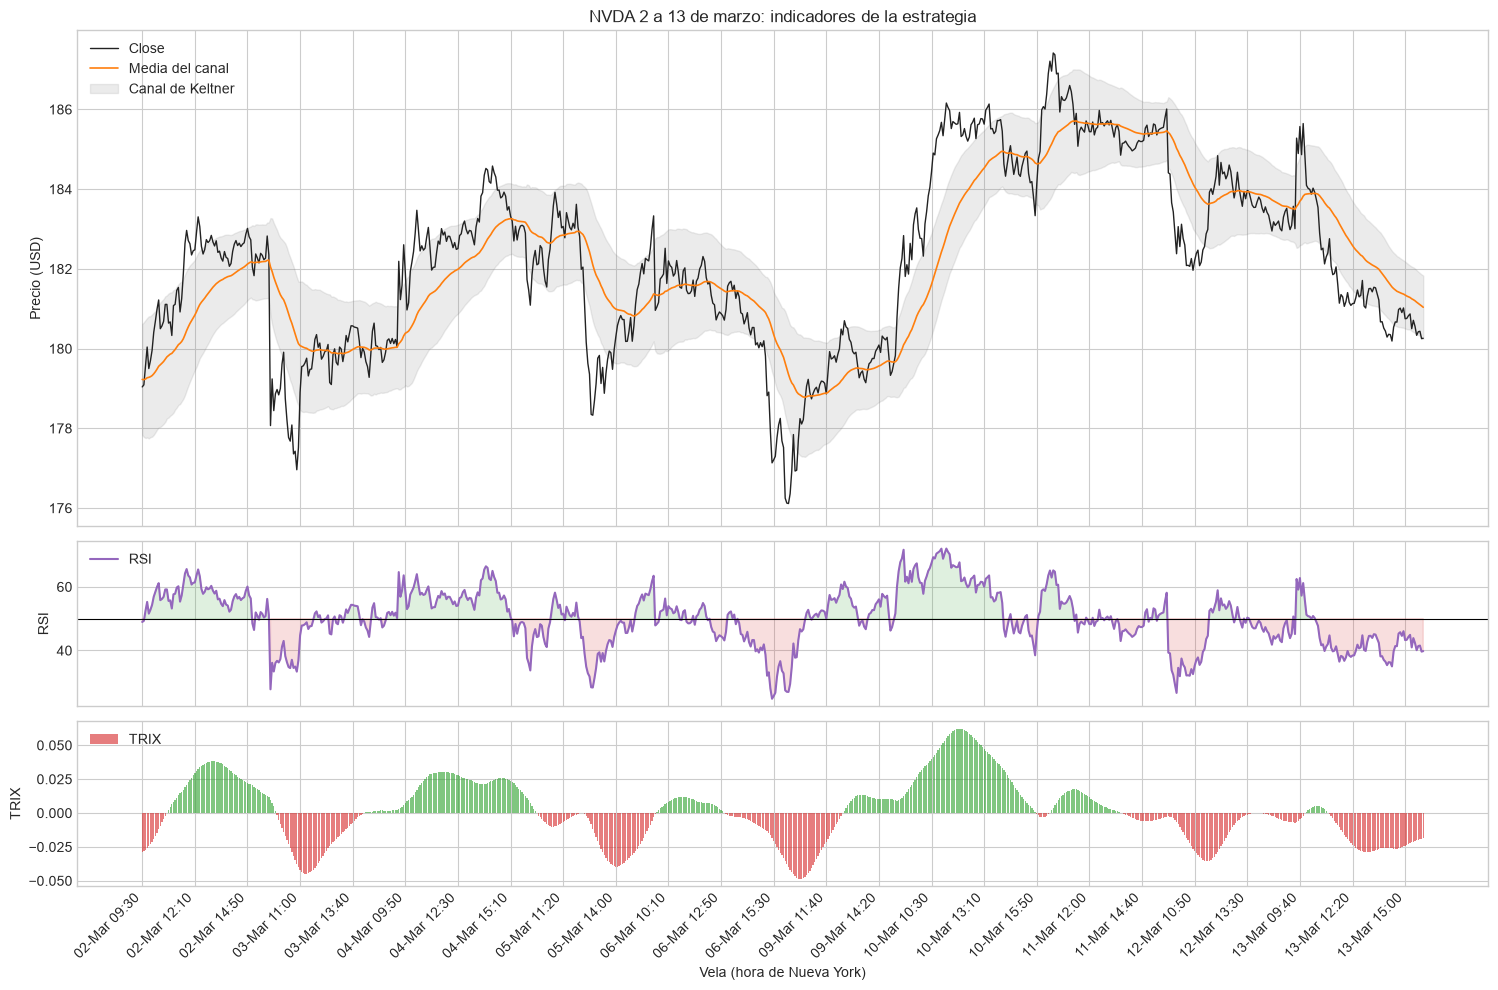

In [5]:
indicadores = calcular_indicadores(train, PARAMETROS_BASE)
plot_indicadores(indicadores.loc[EJEMPLO], titulo="NVDA 2 a 13 de marzo: indicadores de la estrategia")
plt.show()

## 3. Señales: 2 de 3 votos y posición objetivo a favor de la tendencia diaria

In [6]:
senales = generar_senales(train)
cambios = senales["objetivo"].ne(senales["objetivo"].shift())
senales.loc[cambios, ["Close", "kc_low", "kc_high", "rsi", "trix", "volatilidad", "momento", "tendencia",
                      "senal", "tendencia_diaria", "objetivo"]].iloc[1:11].round(4)

,Close,kc_low,kc_high,rsi,trix,volatilidad,momento,tendencia,senal,tendencia_diaria,objetivo
Datetime,,,,,,,,,,,
2026-02-03 09:30:00-05:00,184.1699,186.9591,189.0597,20.1201,-0.0277,0,-1,-1,-1,-1,-1
2026-02-05 09:30:00-05:00,175.2600,173.4930,176.4405,51.5291,0.0003,0,1,1,1,-1,0
2026-02-05 10:20:00-05:00,172.1800,172.6667,176.4021,41.1525,-0.0009,0,-1,-1,-1,-1,-1
2026-02-05 12:40:00-05:00,175.3570,172.7697,176.0158,54.9388,0.0009,0,1,1,1,-1,0
2026-02-05 14:25:00-05:00,173.6700,172.9193,175.4912,46.3700,-0.0001,0,-1,-1,-1,-1,-1
2026-02-06 09:55:00-05:00,180.5569,172.9813,176.6059,71.4821,0.0027,0,1,1,1,-1,0
2026-02-09 09:30:00-05:00,187.3007,183.2756,185.7464,67.6632,0.0383,1,1,1,1,1,1
2026-02-09 15:30:00-05:00,189.7401,189.7785,191.6280,40.3083,0.0047,-1,-1,1,-1,1,0
2026-02-11 09:40:00-05:00,192.8700,188.3033,190.8639,67.6955,-0.0049,1,1,-1,1,1,1


In [7]:
pd.DataFrame({modo: contar_aperturas(generar_senales(train, modo=modo)["objetivo"]) for modo in MODOS})

,dos_de_tres,estricta,solo_keltner,solo_rsi,solo_trix
compras,28,18,21,142,23
ventas,21,15,15,106,22


## 4. Backtest con parámetros base

In [8]:
resultado_base = backtest(senales, senales["objetivo"])
resultado_base["operaciones"].head(10).round(2)

/var/folders/pk/r0skg4n15qn2ngdpl5bhng2w0000gn/T/ipykernel_34622/15582090.py:2: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  resultado_base["operaciones"].head(10).round(2)


,tipo,lado,entrada,precio_entrada,acciones,stop_loss,take_profit,comision,deslizamiento,prestamo,riesgo_usd,regimen,salida,precio_salida,motivo,velas,pnl
0,dia,-1,2026-02-03 09:35:00-05:00,184.12,1402.49,187.71,173.03,626.17,67.99,7.26,5000.00,None,2026-02-04 12:35:00-05:00,173.06,take_profit,114,14881.92
1,dia,-1,2026-02-05 10:25:00-05:00,172.14,777.16,178.70,151.82,337.64,37.28,0.96,5074.41,None,2026-02-05 12:45:00-05:00,175.42,objetivo,28,-2886.12
2,dia,-1,2026-02-05 14:30:00-05:00,173.63,1528.45,176.96,163.33,669.87,66.89,1.21,5059.98,None,2026-02-06 09:30:00-05:00,176.98,stop_loss,18,-5797.95
3,dia,1,2026-02-09 09:35:00-05:00,187.32,1179.53,183.03,200.59,555.92,45.83,0.00,5030.99,None,2026-02-09 15:35:00-05:00,189.72,objetivo,72,2276.30
4,dia,1,2026-02-11 09:45:00-05:00,192.90,979.83,187.73,208.91,472.66,37.52,0.00,5042.37,None,2026-02-12 09:30:00-05:00,193.02,objetivo,75,-358.31
5,dia,1,2026-02-12 09:35:00-05:00,192.18,1374.59,188.49,203.58,658.57,62.85,0.00,5040.58,None,2026-02-12 10:05:00-05:00,191.11,objetivo,6,-2130.38
6,dia,1,2026-02-12 10:15:00-05:00,191.69,1125.78,187.20,205.59,538.93,51.78,0.00,5029.93,None,2026-02-12 10:20:00-05:00,191.29,objetivo,1,-990.26
7,dia,1,2026-02-12 10:25:00-05:00,191.71,1138.68,187.27,205.44,544.61,52.17,0.00,5024.98,None,2026-02-12 10:35:00-05:00,190.92,objetivo,2,-1445.22
8,dia,-1,2026-02-17 09:35:00-05:00,182.37,1284.75,186.30,170.22,588.78,65.45,1.18,5017.75,None,2026-02-17 11:15:00-05:00,184.26,objetivo,20,-3019.36
9,dia,-1,2026-02-18 14:55:00-05:00,187.55,2102.61,189.95,180.15,983.91,87.44,1.40,5002.65,None,2026-02-19 09:35:00-05:00,186.80,objetivo,14,588.32


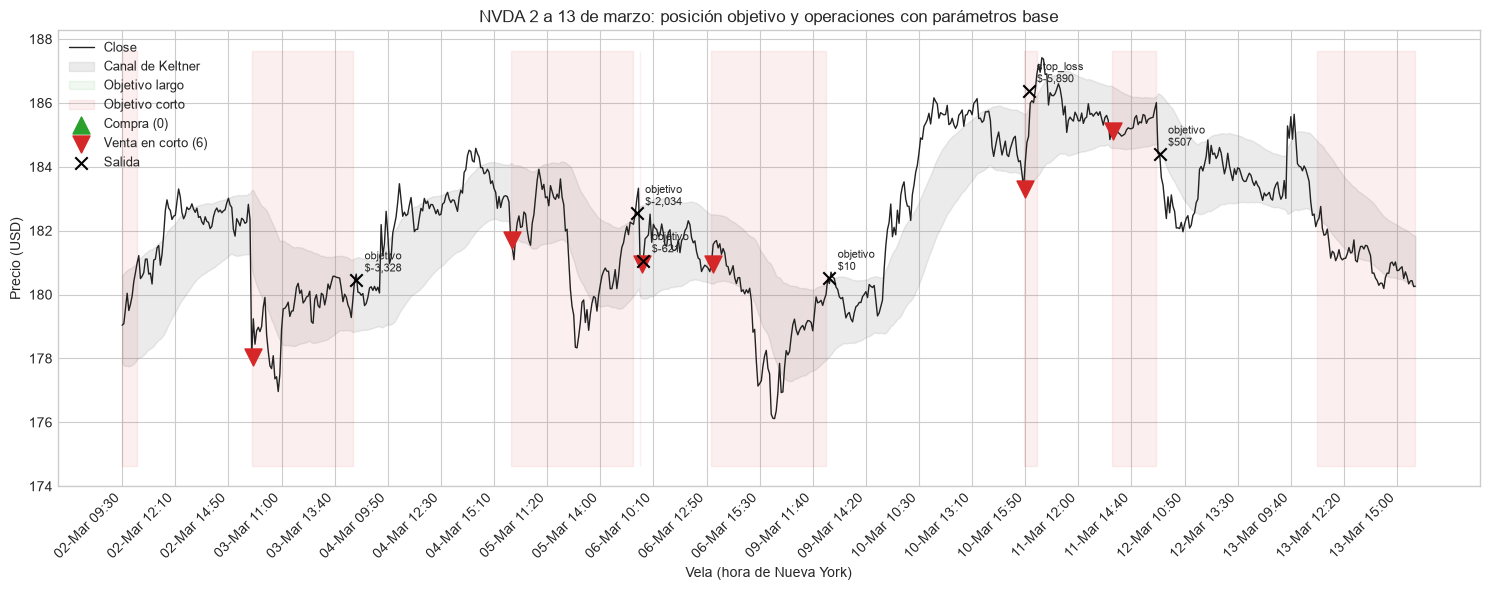

In [9]:
plot_operaciones(senales.loc[EJEMPLO], resultado_base["operaciones"], titulo="NVDA 2 a 13 de marzo: posición objetivo y operaciones con parámetros base")
plt.show()

## 5. Espacio de búsqueda de θ

In [10]:
pd.DataFrame([{"parámetro": k, "mínimo": v[0], "máximo": v[1], "justificación": v[3]} for k, v in RANGOS.items()]).set_index("parámetro")

,mínimo,máximo,justificación
parámetro,,,
sl_atr,2.0000,8.000,"stop amplio, porque la posición pasa la noche ..."
tp_atr,4.0000,24.000,objetivo que supere varias veces el costo de 0...
riesgo,0.0025,0.010,tamaño de posición: tocar el stop cuesta de 0....
umbral_vwap,0.0030,0.008,compra nocturna: cierre de 0.3% a 0.8% bajo el...
tamano_noche,0.2500,1.000,compra nocturna: fracción del equity (sin apal...


In [11]:
print(f"Restricción: menos de {MIN_OPERACIONES} operaciones abiertas en el régimen dentro de la ventana → Calmar = −10")

Restricción: menos de 4 operaciones abiertas en el régimen dentro de la ventana → Calmar = −10


## 6. Detección de régimen: reglas, K-means y HMM

Los tres clasificadores se ajustan solo con train. El HMM etiqueta con probabilidades filtradas (solo información hasta t); Viterbi se muestra para comparar porque reetiqueta el pasado con el futuro.

In [12]:
pd.read_csv(RES / "clasificadores.csv", index_col=[0, 1]).round(3)

silhouette  duracion_media_h  transiciones_por_mes  \
reglas      train       0.283            17.417                 7.620   
            test        0.195            12.705                10.256   
kmeans      train       0.387            13.630                 9.797   
            test        0.290            17.469                 7.326   
hmm         train       0.360            17.914                 7.402   
            test        0.128            17.469                 7.326   
hmm_viterbi train       0.375            16.946                 7.837   
            test        0.135            13.975                 9.279   

                   part_tendencia  part_reversion  part_crisis  
reglas      train           0.274           0.477        0.249  
            test            0.215           0.275        0.510  
kmeans      train           0.255           0.317        0.427  
            test            0.129           0.462        0.410  
hmm         train           0.185           0.394        0.421  
            test            0.014           0.533        0.453  
hmm_viterbi train           0.191           0.375        0.434  
            test            0.029           0.519        0.453

Coincidencia HMM filtrado vs Viterbi en train: 98.2%


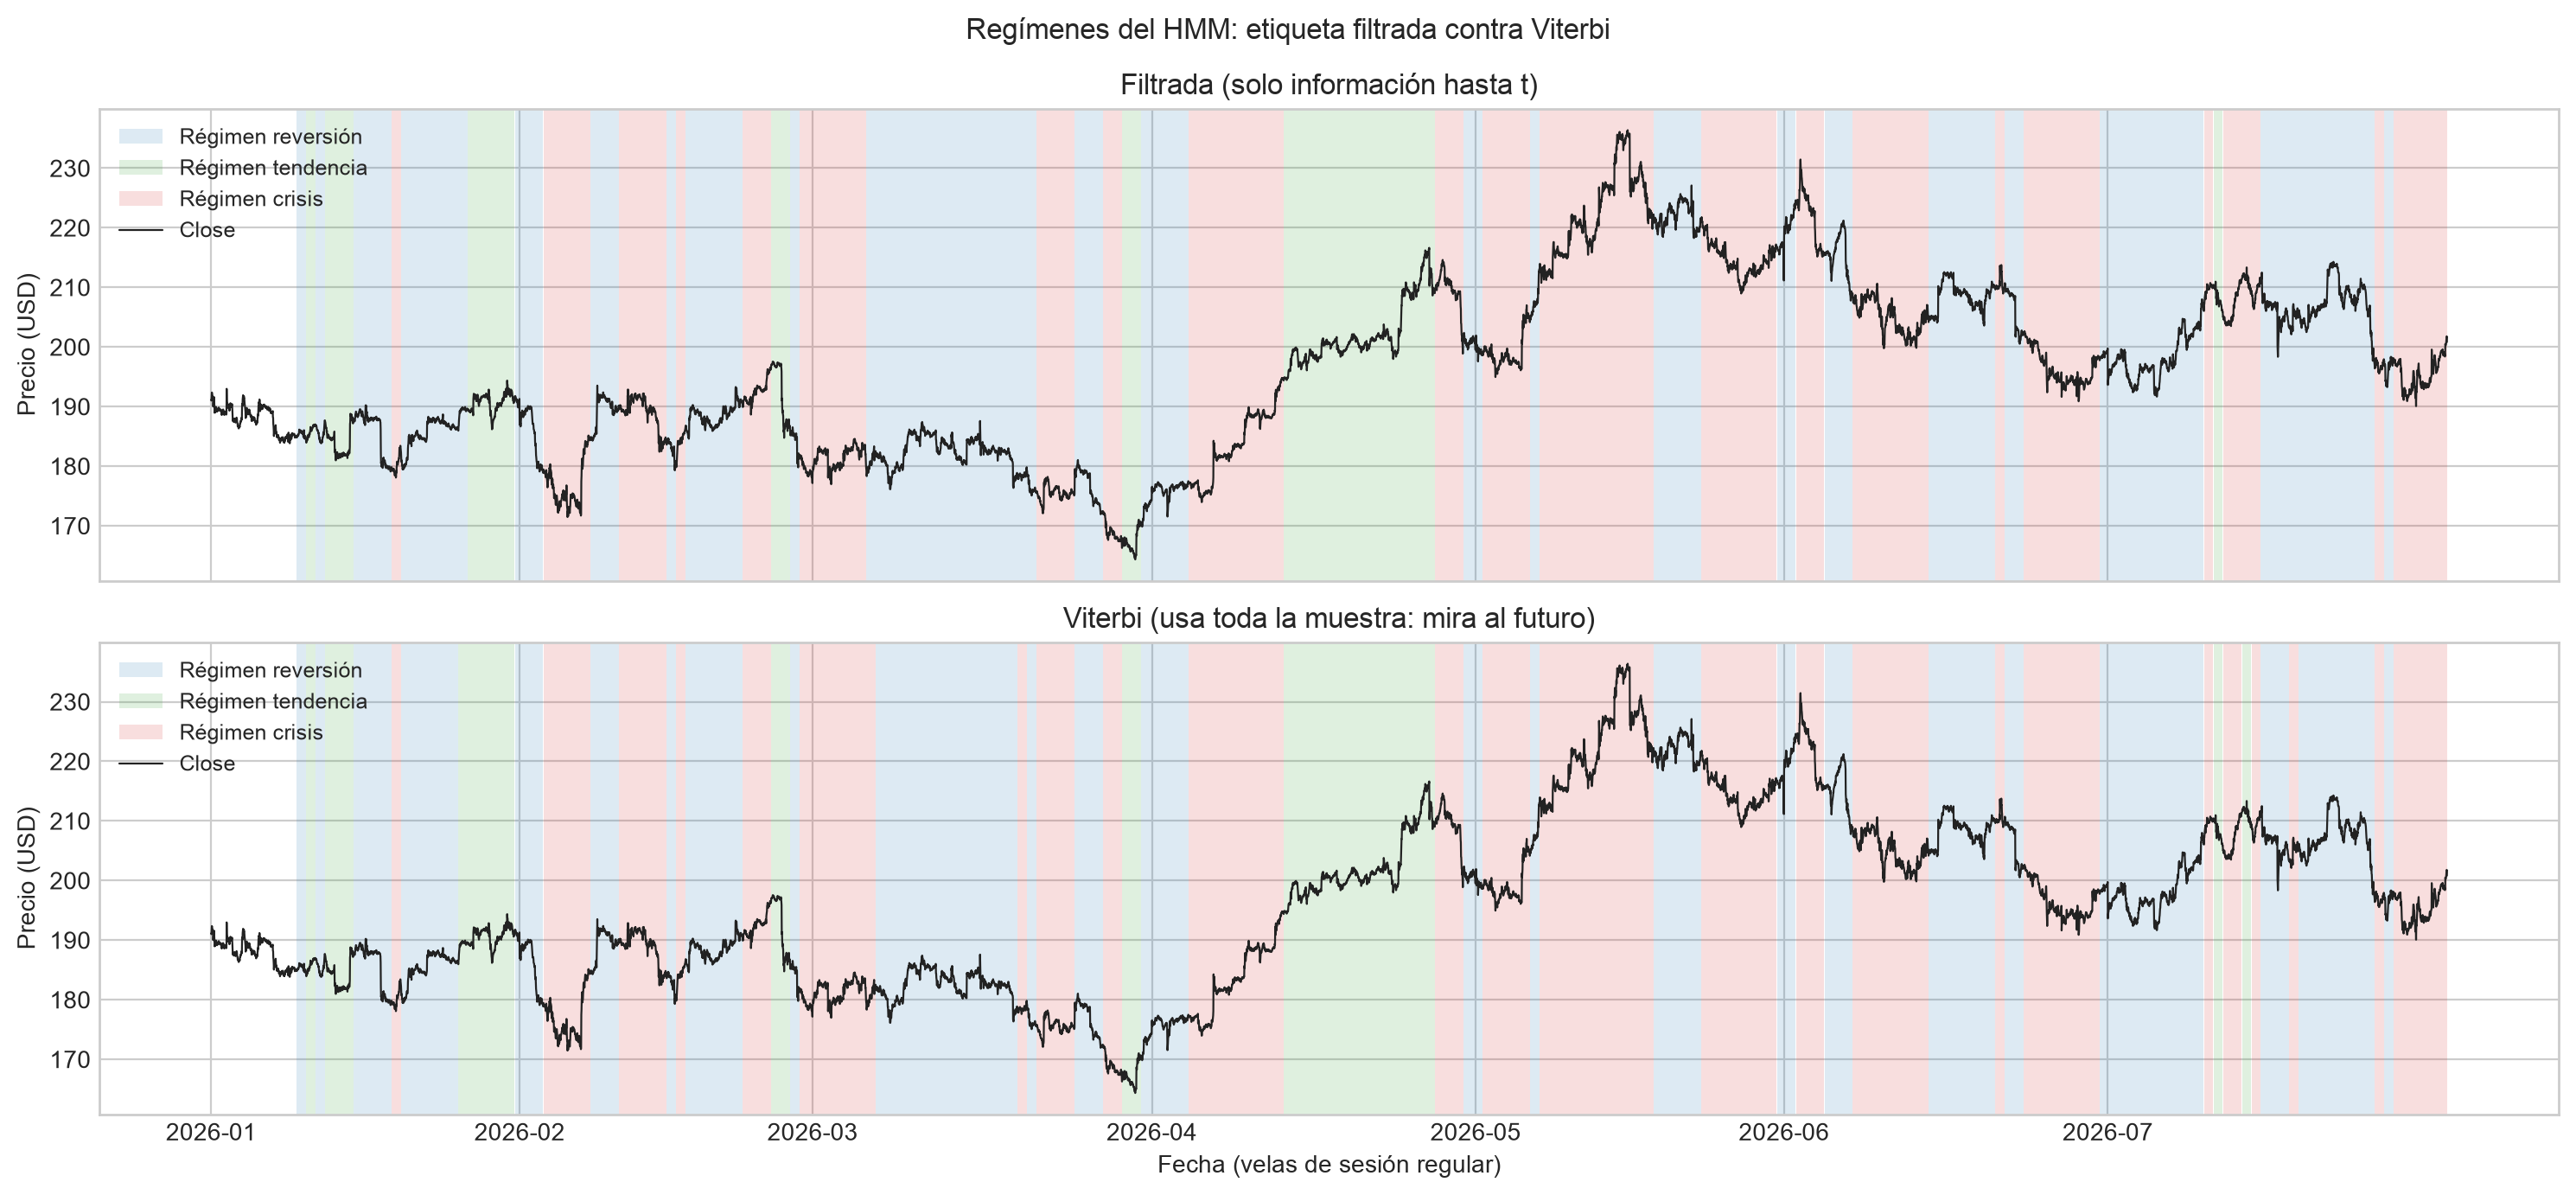

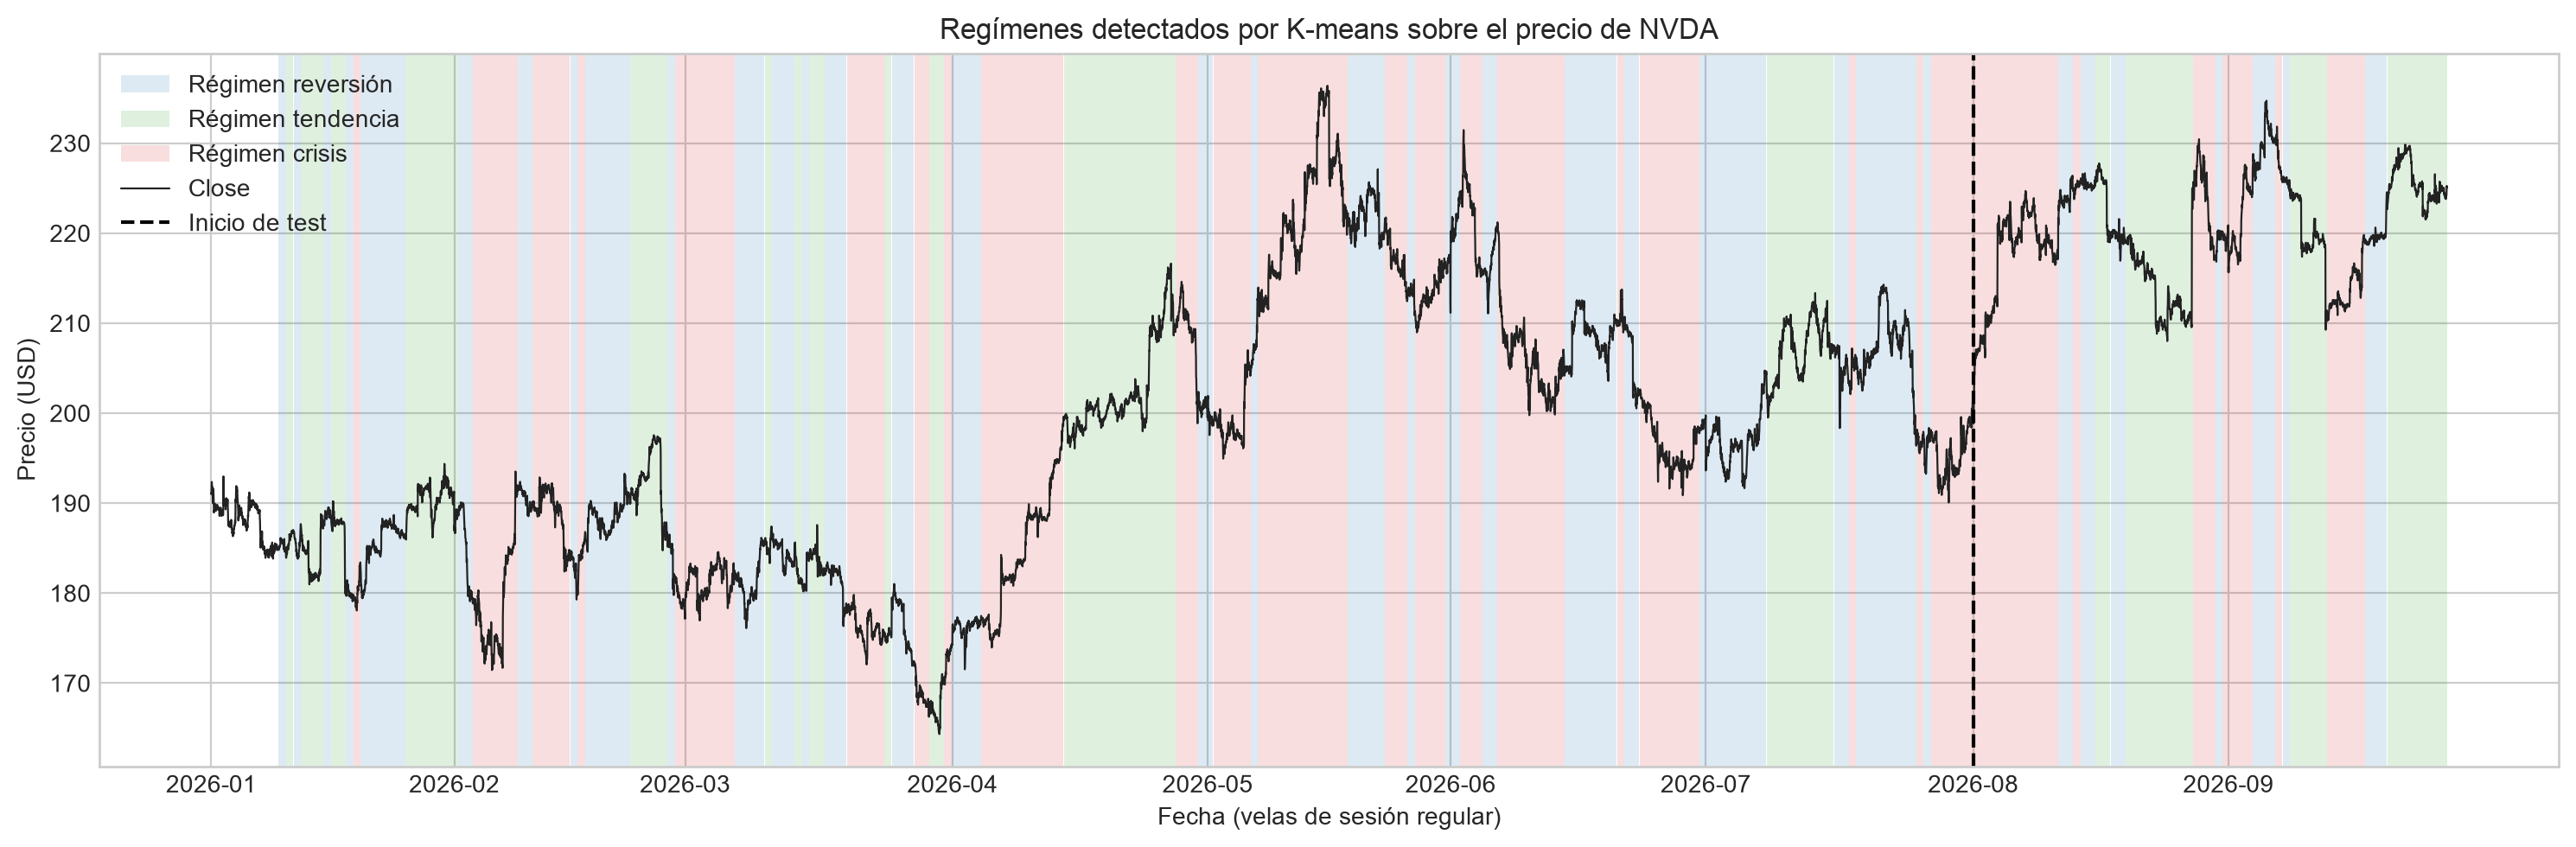

In [13]:
print(f"Coincidencia HMM filtrado vs Viterbi en train: {resumen['coincidencia_filtrada_viterbi']:.1%}")
display(Image(FIG / "15_hmm_filtrada_viterbi.png"))
display(Image(FIG / "07_regimenes_precio.png"))

Elijo K-means: tiene el mejor silhouette en train y en test y conserva los tres regímenes fuera de muestra; el HMM casi no detecta tendencia en test.

## 7. Optimización en dos etapas: ventanas con todo train y lo operativo por régimen (random search contra TPE)

In [14]:
e1 = resumen["etapa1"]
print(f"Etapa 1: TPE N = {e1['pruebas']} · mejor Calmar {e1['calmar']:.2f} · meseta {e1['calmar_meseta']:.2f} · {e1['segundos']:.0f} s")
pd.Series(e1["ventanas"]).to_frame("ventana elegida")

Etapa 1: TPE N = 200 · mejor Calmar 10.39 · meseta 8.85 · 25 s


,ventana elegida
kc_n,50
kc_atr,26
rsi_n,15
trix_n,28
memoria,15
dias_tendencia,20


In [15]:
diag = pd.DataFrame(resumen["diagnostico"]).T
diag[["n_random", "mejor_random", "n_tpe", "mejor_tpe", "meseta_tpe", "theta_es_argmax", "activo"]]

,n_random,mejor_random,n_tpe,mejor_tpe,meseta_tpe,theta_es_argmax,activo
tendencia,200,3.507275,200,10.914974,10.021508,False,True
reversion,200,5.998407,200,8.634987,7.621408,False,True
crisis,200,14.743914,200,18.073519,17.331774,False,True


In [16]:
for regimen, d in resumen["diagnostico"].items():
    print(f"{regimen}: random search N = {d['n_random']} trials · TPE N = {d['n_tpe']} trials · "
          f"mejor Calmar TPE = {d['mejor_tpe']:.2f}")

tendencia: random search N = 200 trials · TPE N = 200 trials · mejor Calmar TPE = 10.91
reversion: random search N = 200 trials · TPE N = 200 trials · mejor Calmar TPE = 8.63
crisis: random search N = 200 trials · TPE N = 200 trials · mejor Calmar TPE = 18.07


Historia de optimización: valor del objetivo por trial y mejor acumulado.

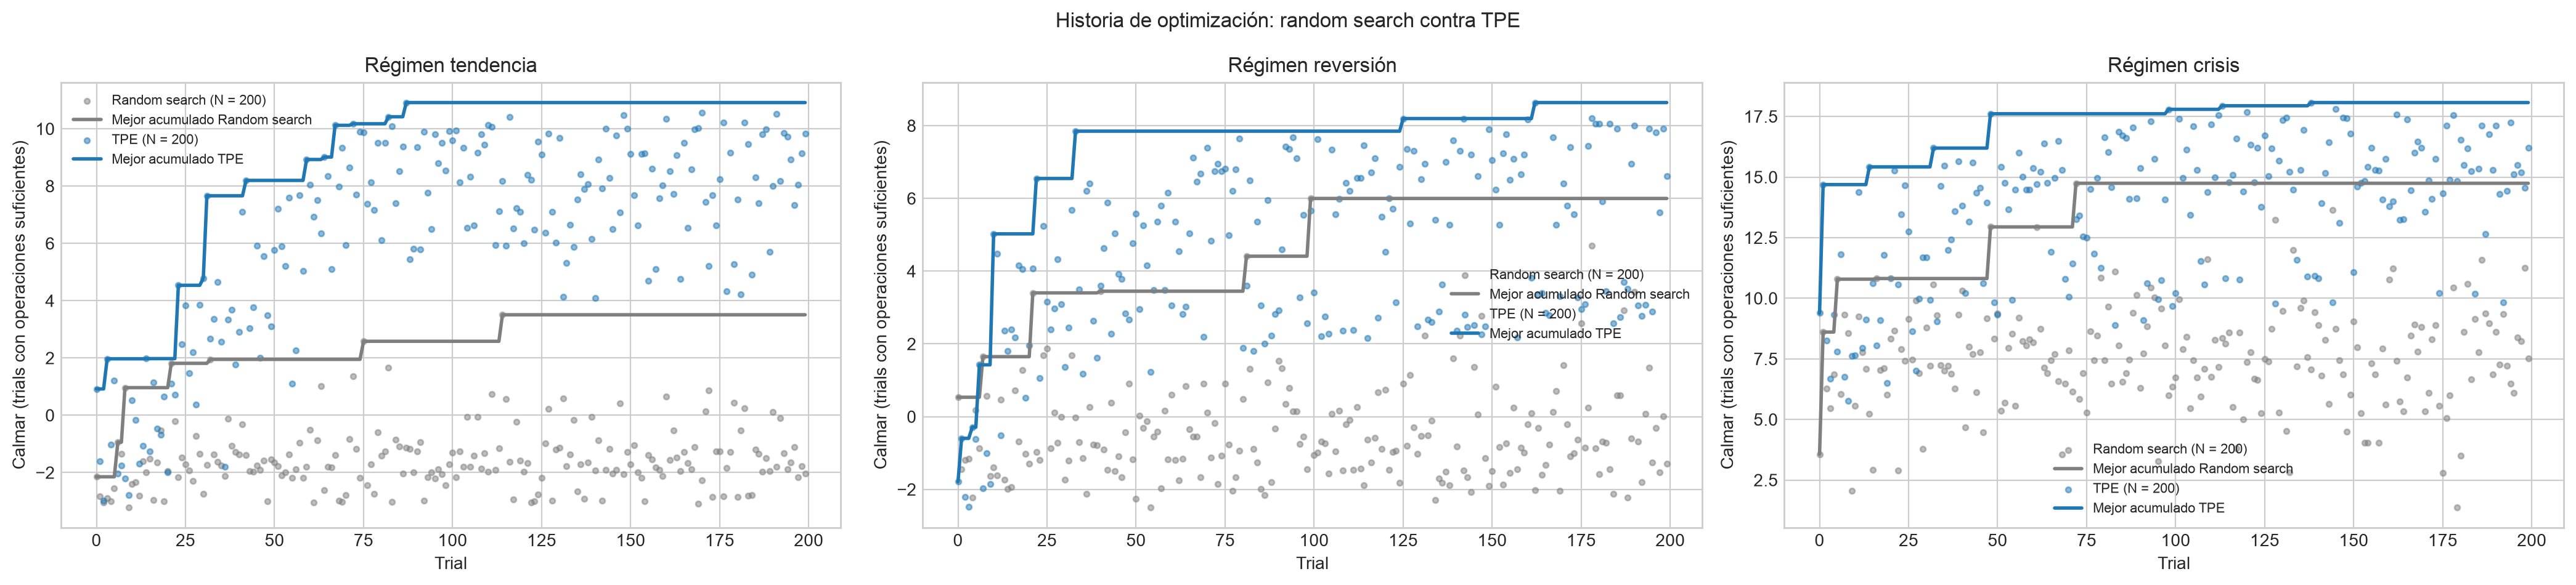

In [17]:
display(Image(FIG / "11_historia_optimizacion.png"))

Importancia de parámetros del TPE: define los ejes de la superficie 3D.

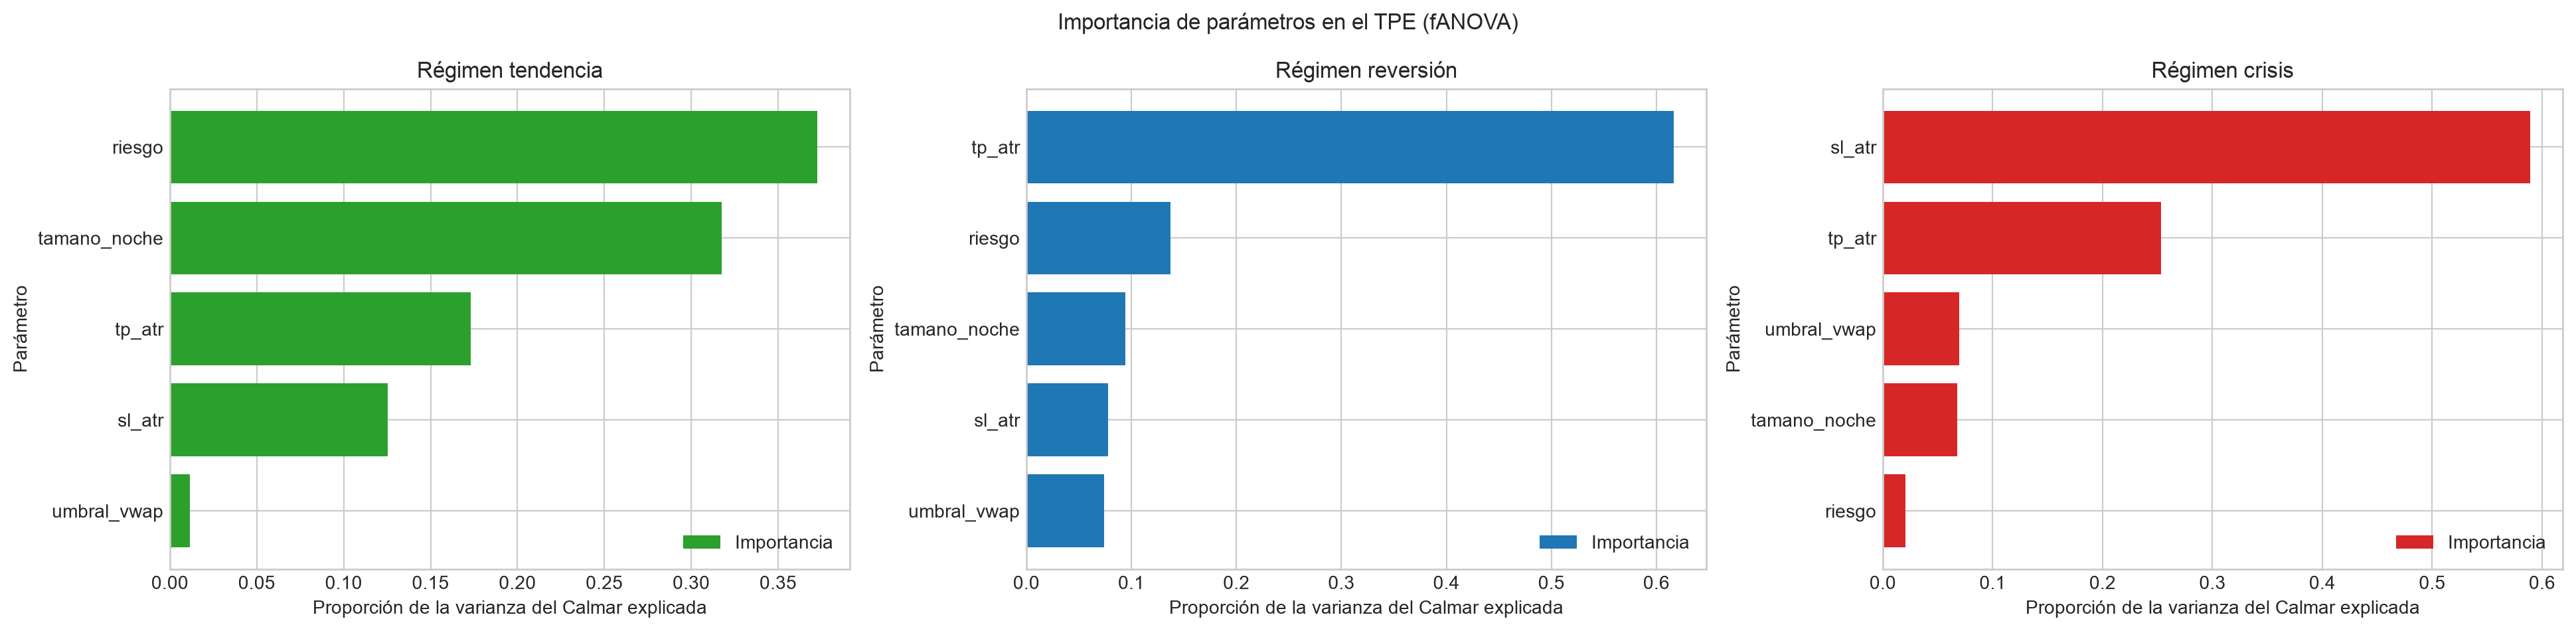

In [18]:
display(Image(FIG / "12_importancia_parametros.png"))

Superficie 3D del Calmar. No existe una superficie completa en más de 2 dimensiones, así que se toma un corte en las dos dimensiones más importantes según el TPE y el resto de θ se fija en el mejor punto del random search.

tendencia → ejes: ['riesgo', 'tamano_noche']


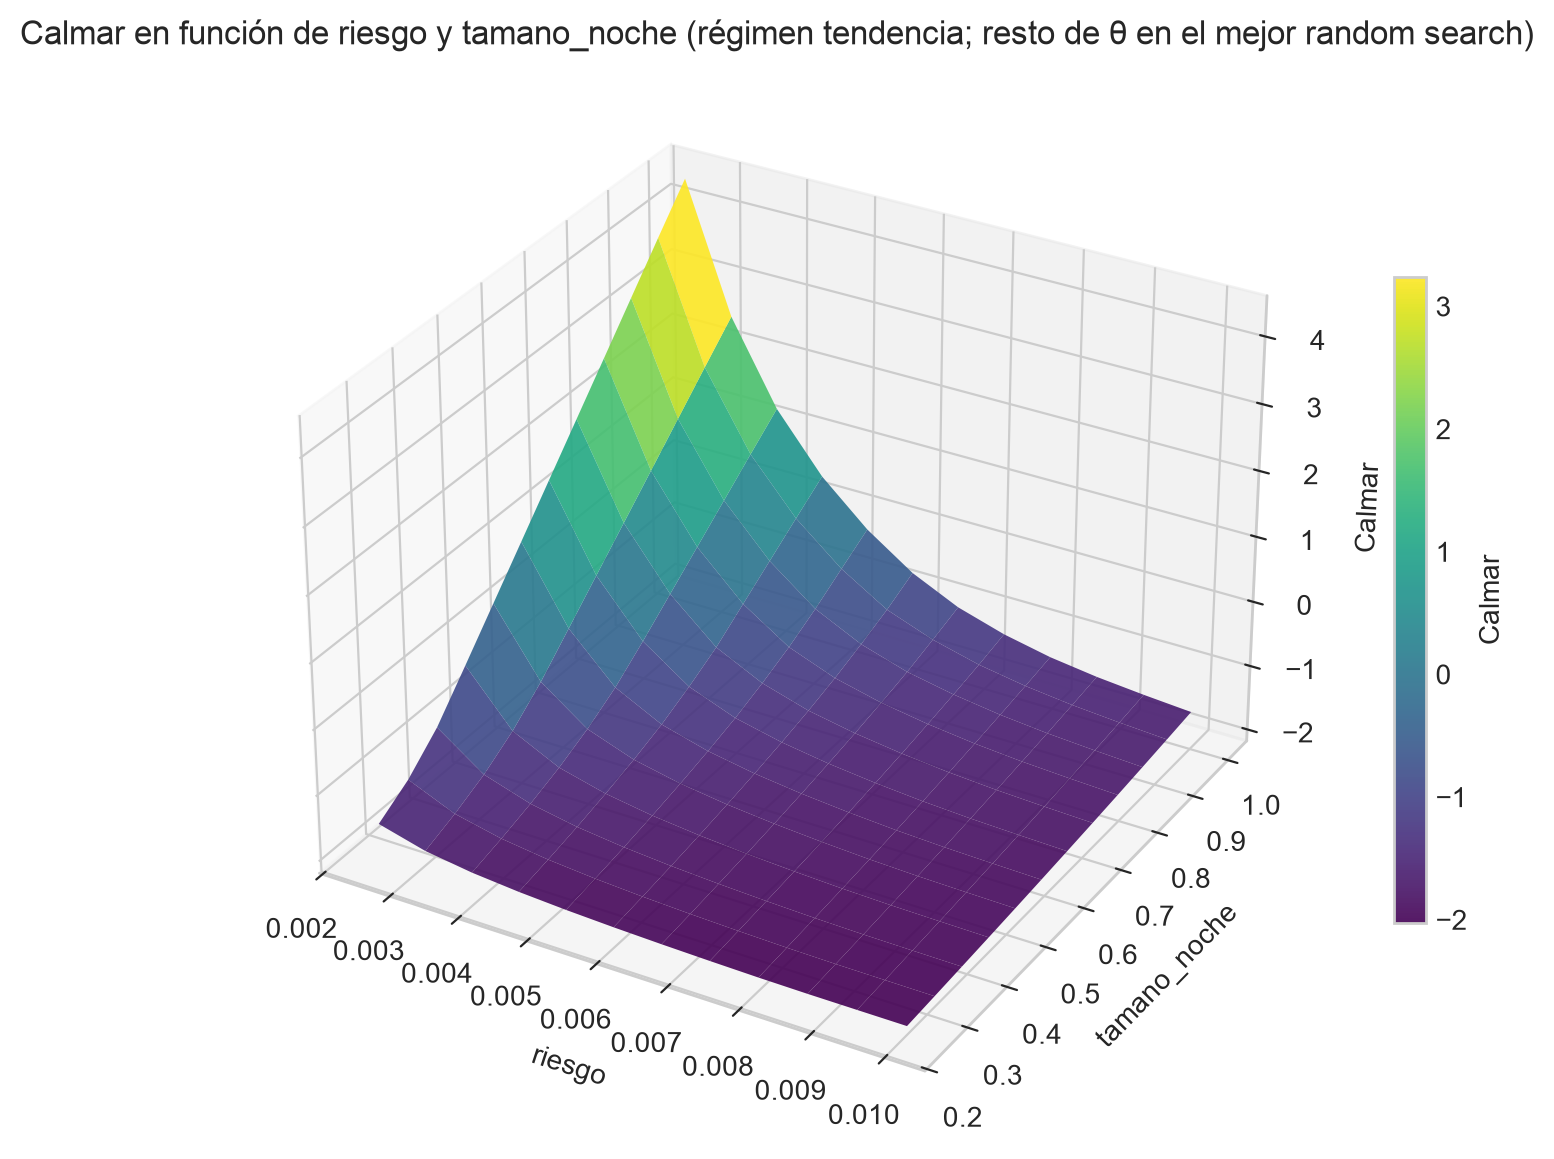

reversion → ejes: ['tp_atr', 'riesgo']


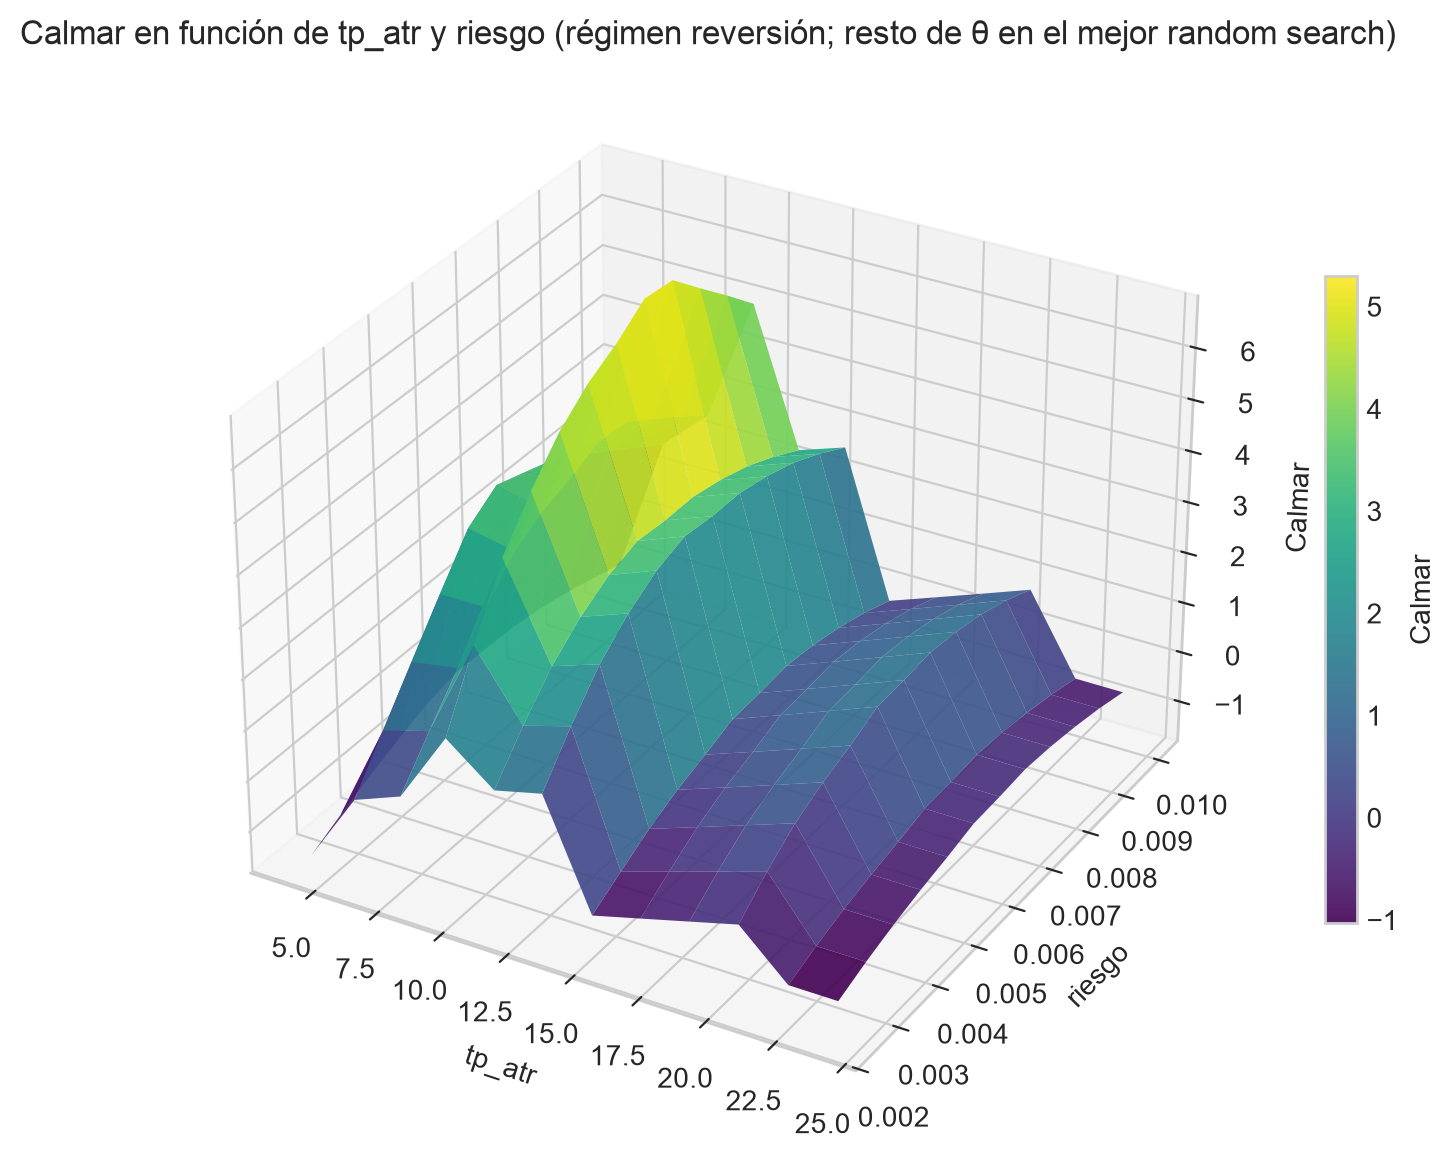

crisis → ejes: ['sl_atr', 'tp_atr']


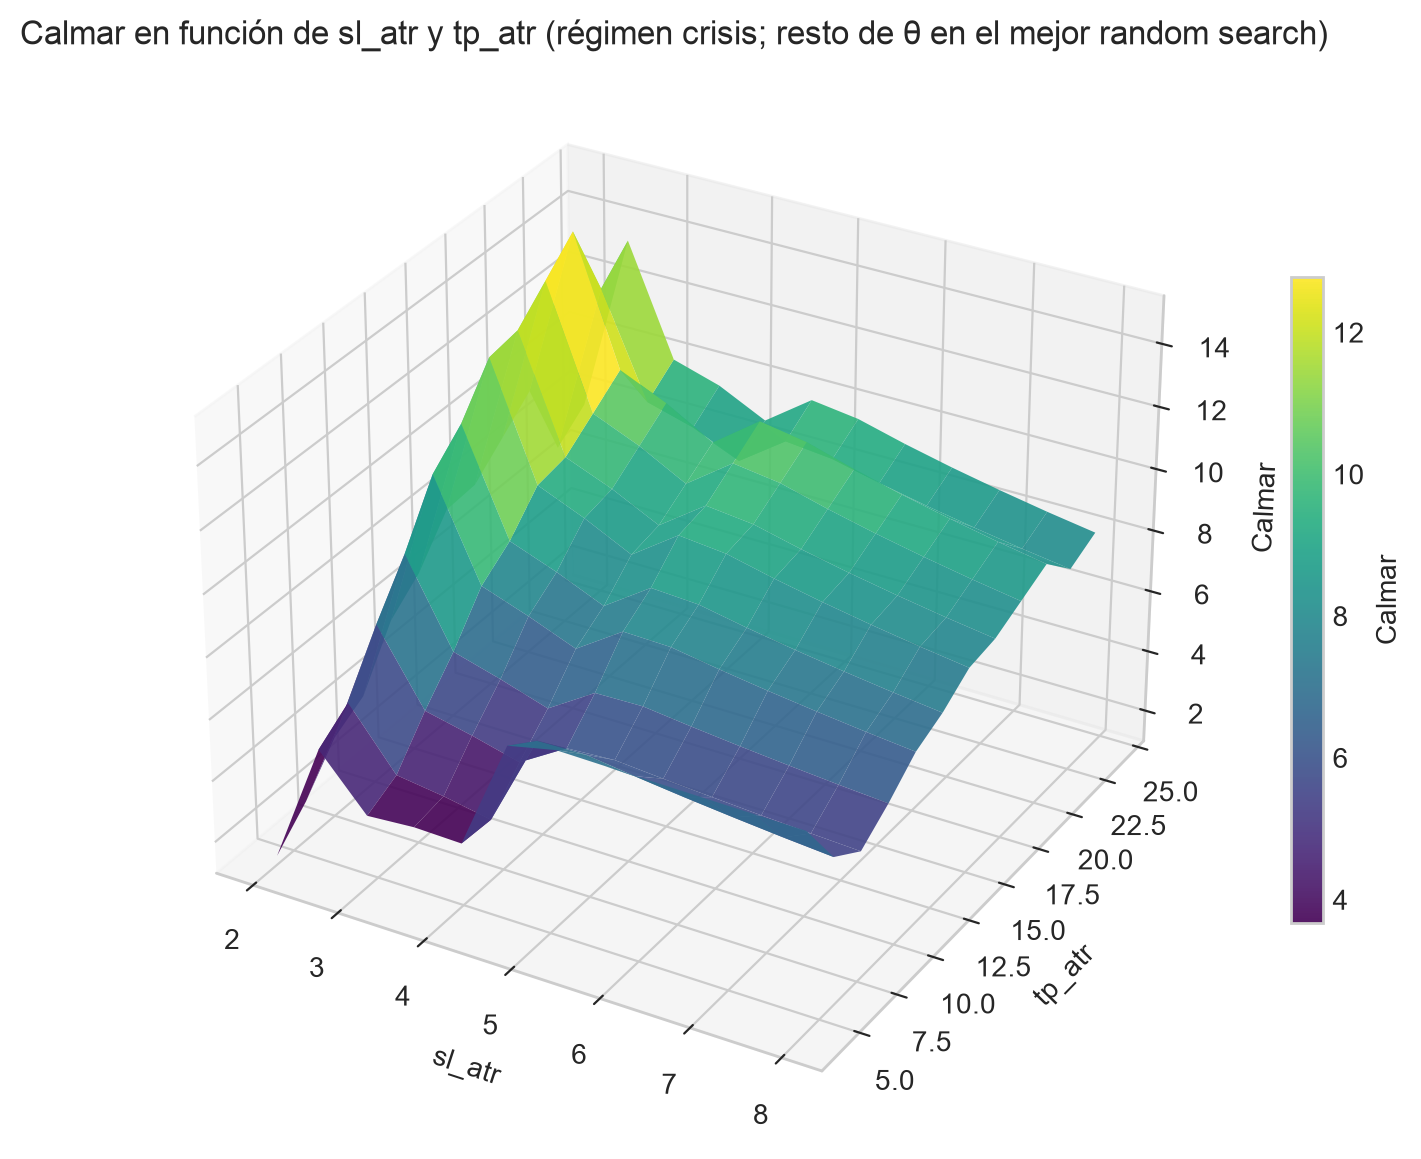

In [19]:
for regimen, d in resumen["diagnostico"].items():
    if "ejes_superficie" in d:
        print(regimen, "→ ejes:", d["ejes_superficie"])
        display(Image(FIG / f"14_superficie_{regimen}.png"))

Slice plots: si el argmax (línea roja) está aislado y sus vecinos dan resultados muy distintos, θ* se toma del centro de la mejor meseta (línea verde), definida como el trial cuyo vecindario de 10 trials tiene el Calmar promedio más alto.

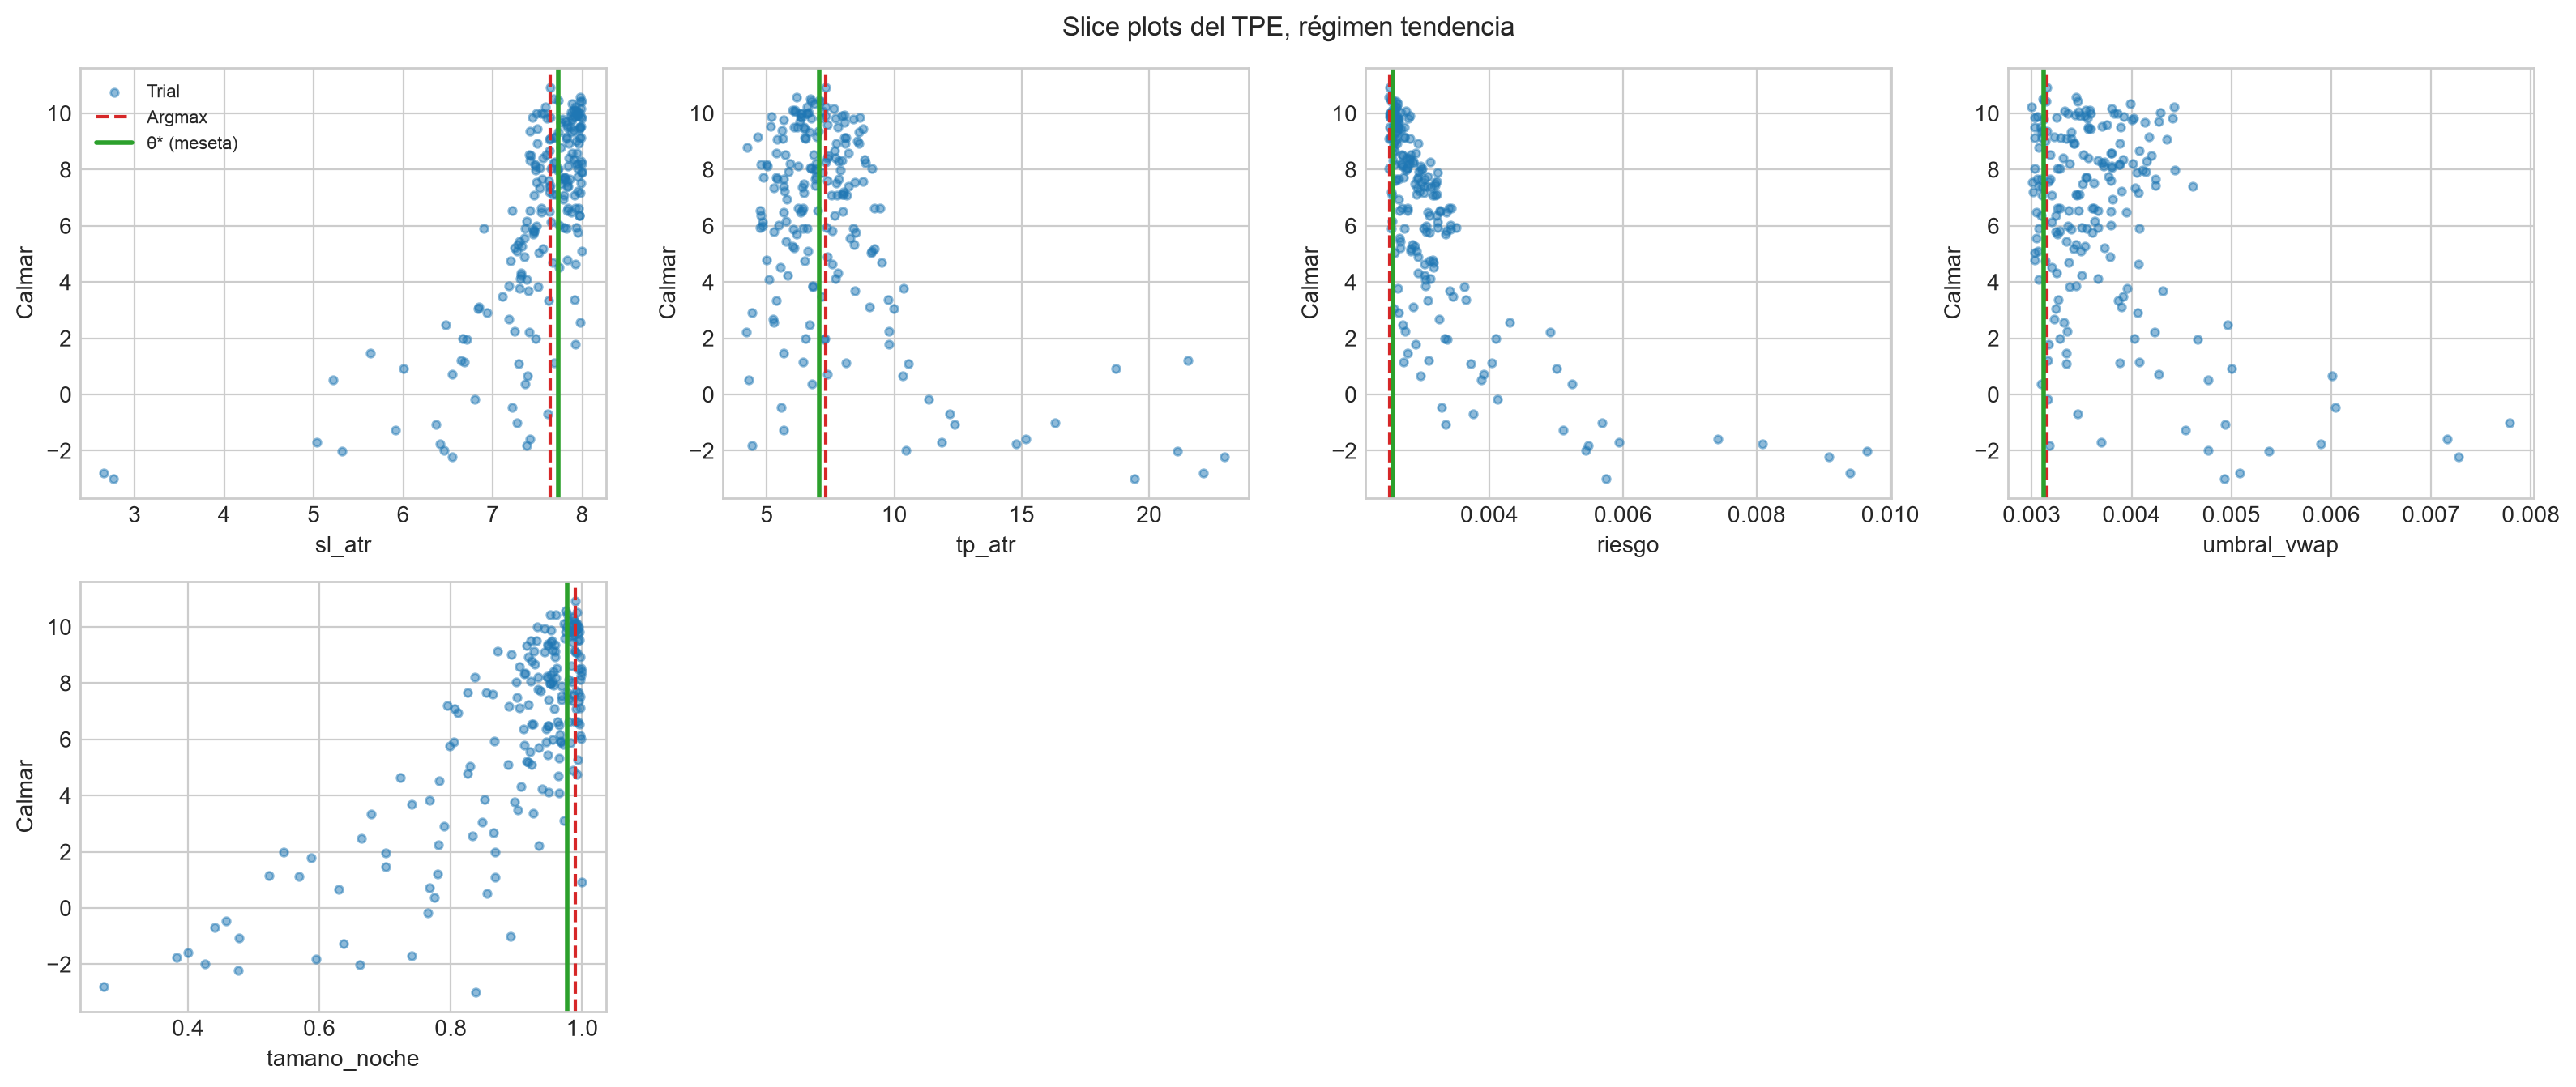

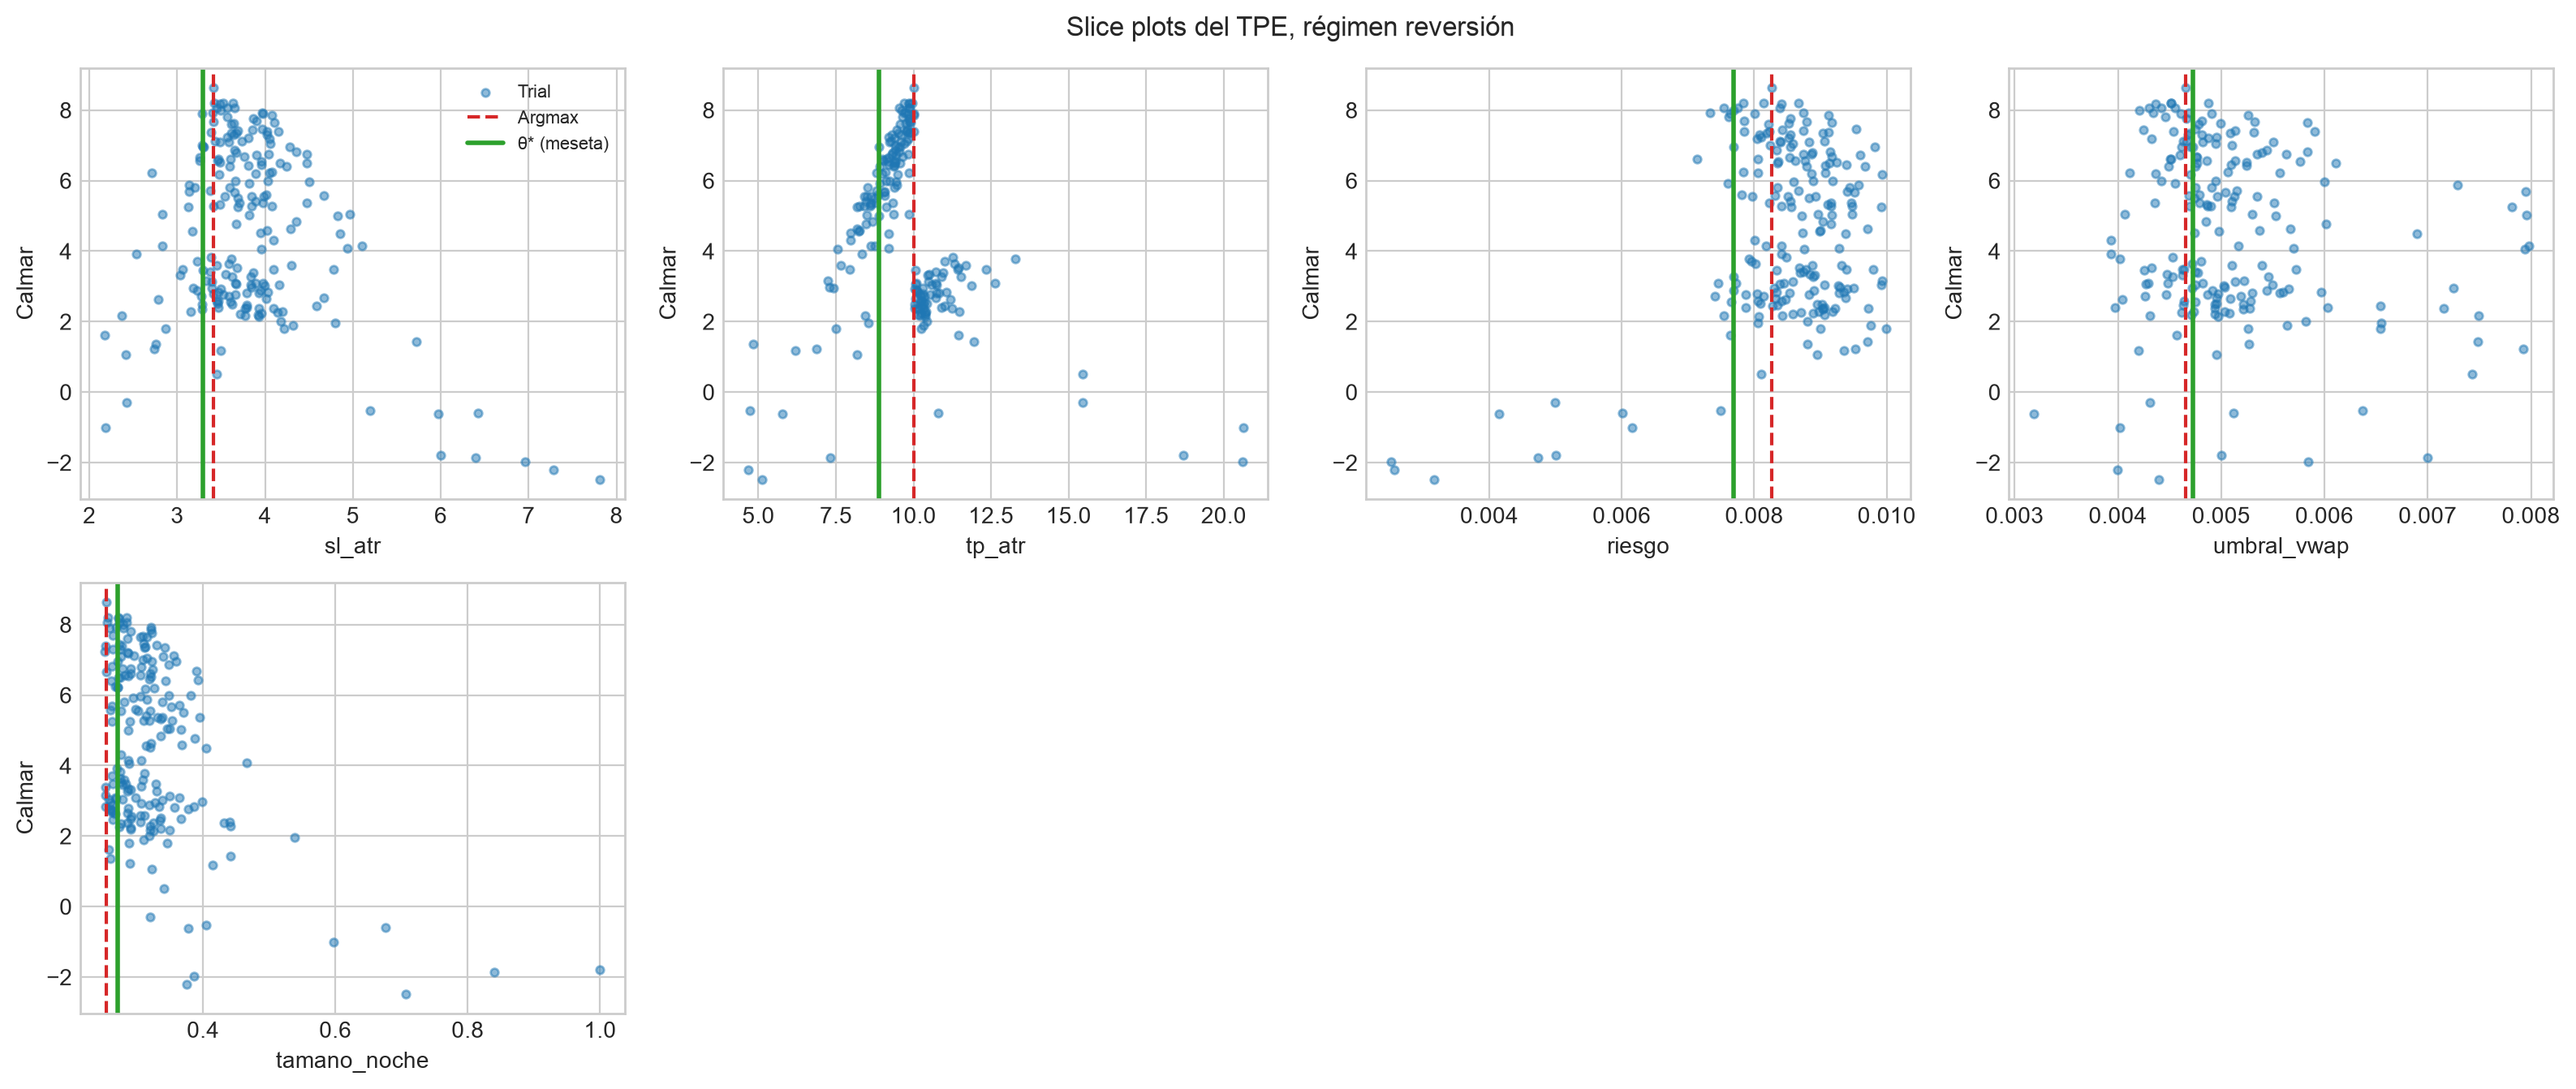

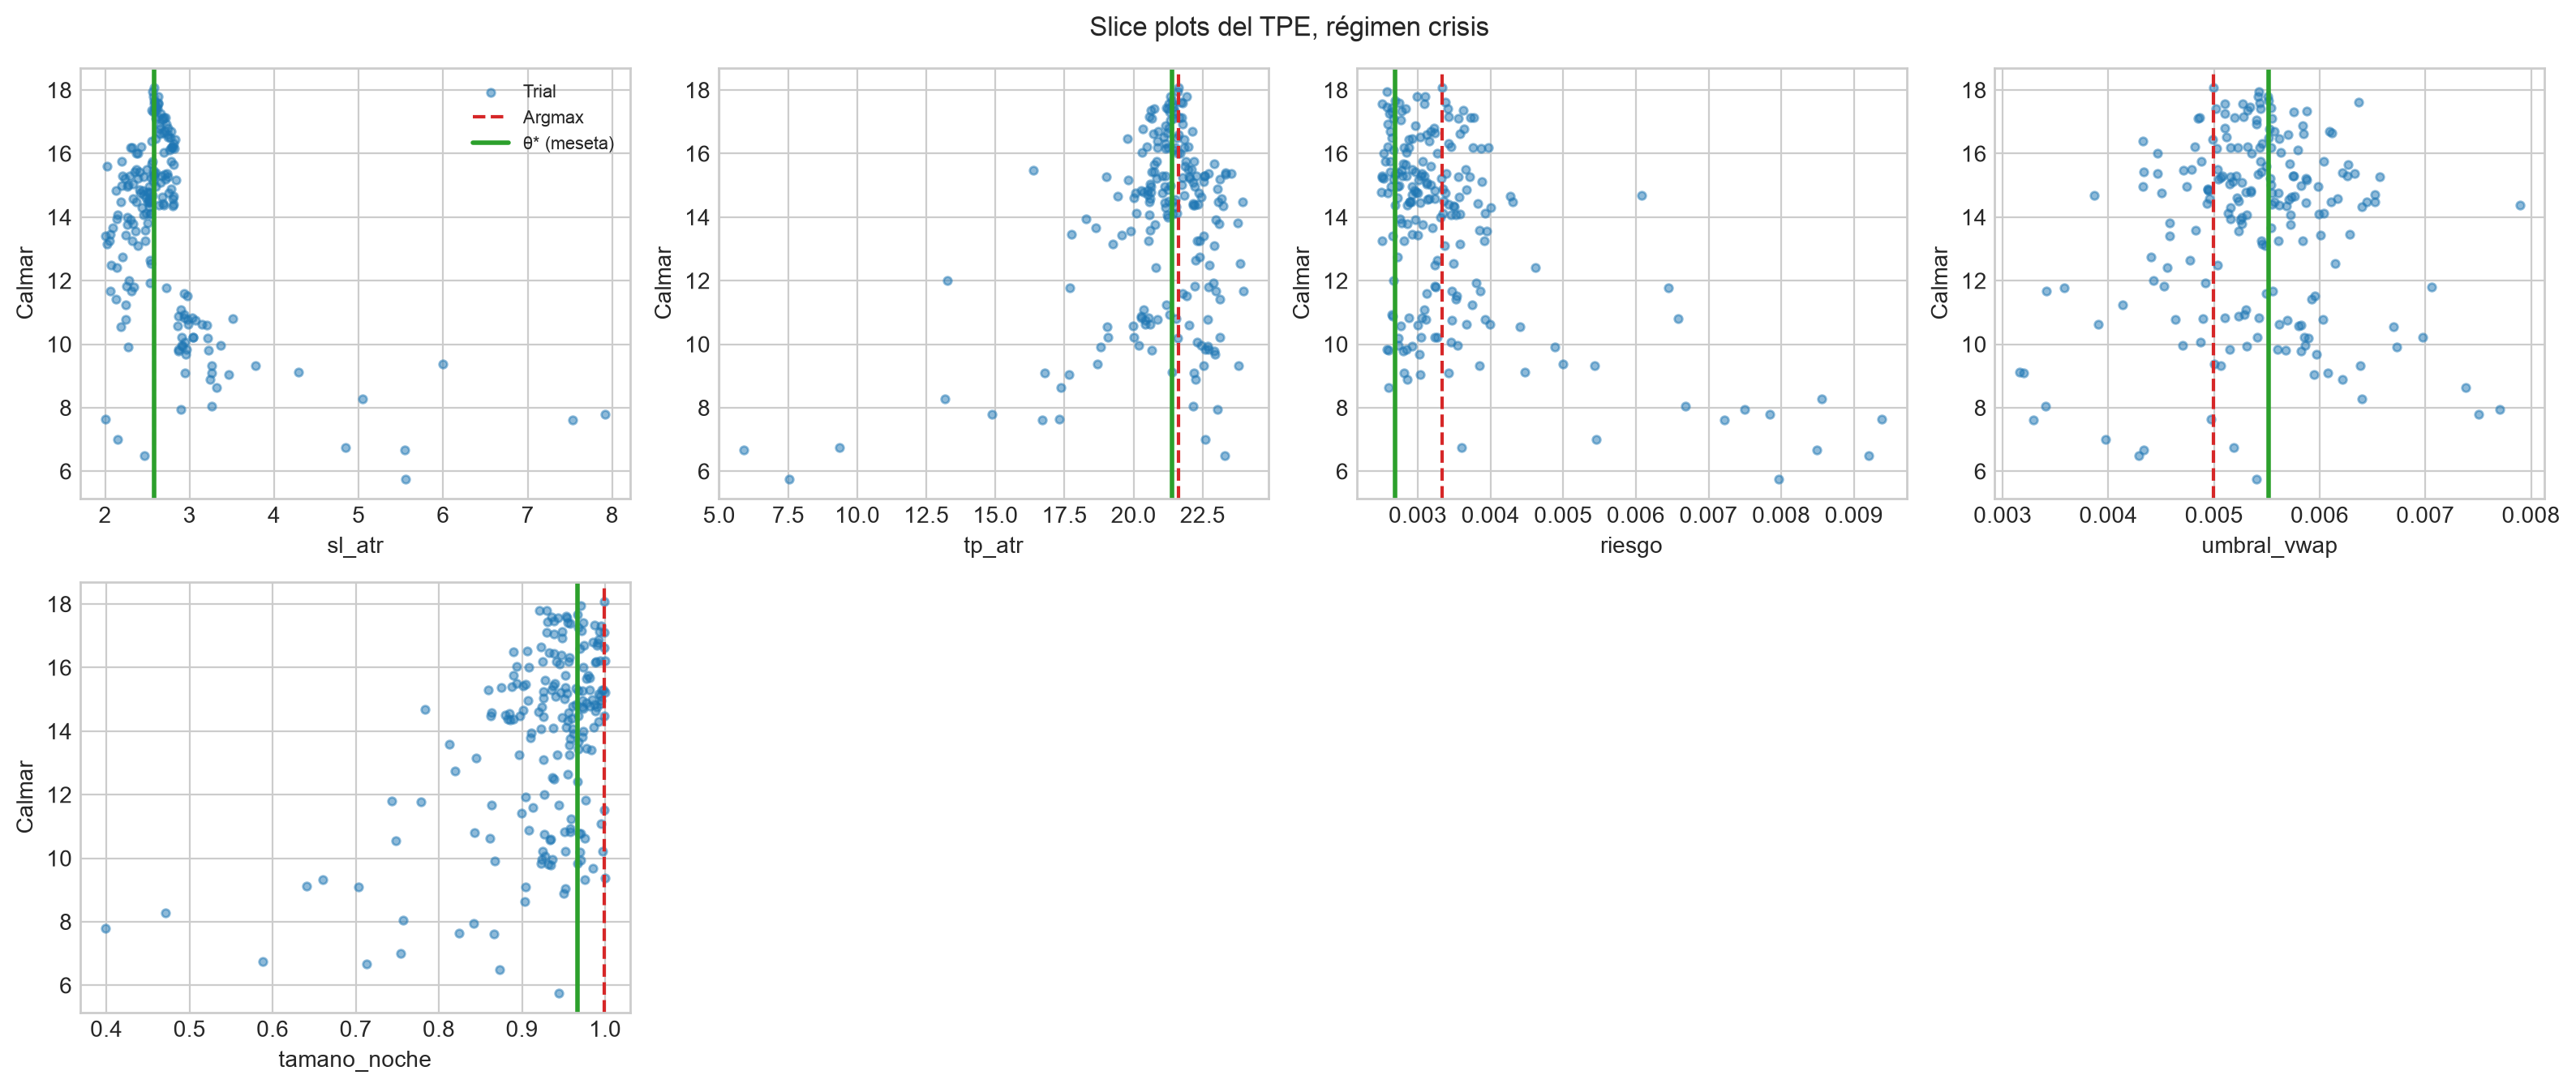

In [20]:
for regimen, d in resumen["diagnostico"].items():
    if "ejes_superficie" in d:
        display(Image(FIG / f"13_slices_{regimen}.png"))

## 8. Walk-forward: 1 mes de entrenamiento, 1 semana de prueba, paso semanal

In [21]:
wf = resumen["walk_forward"]
pd.Series({"ventanas": wf["ventanas"], "configuraciones": wf["configuraciones"], "segundos": round(wf["segundos"]),
           "anualizado dentro": wf["anualizado_dentro"], "anualizado fuera": wf["anualizado_fuera"],
           "retorno fuera": wf["retorno_fuera"], "walk-forward efficiency": wf["eficiencia"]}).to_frame("valor")

,valor
ventanas,24.000000
configuraciones,9900.000000
segundos,323.000000
anualizado dentro,0.850857
anualizado fuera,-0.256152
retorno fuera,-0.126308
walk-forward efficiency,-0.301052


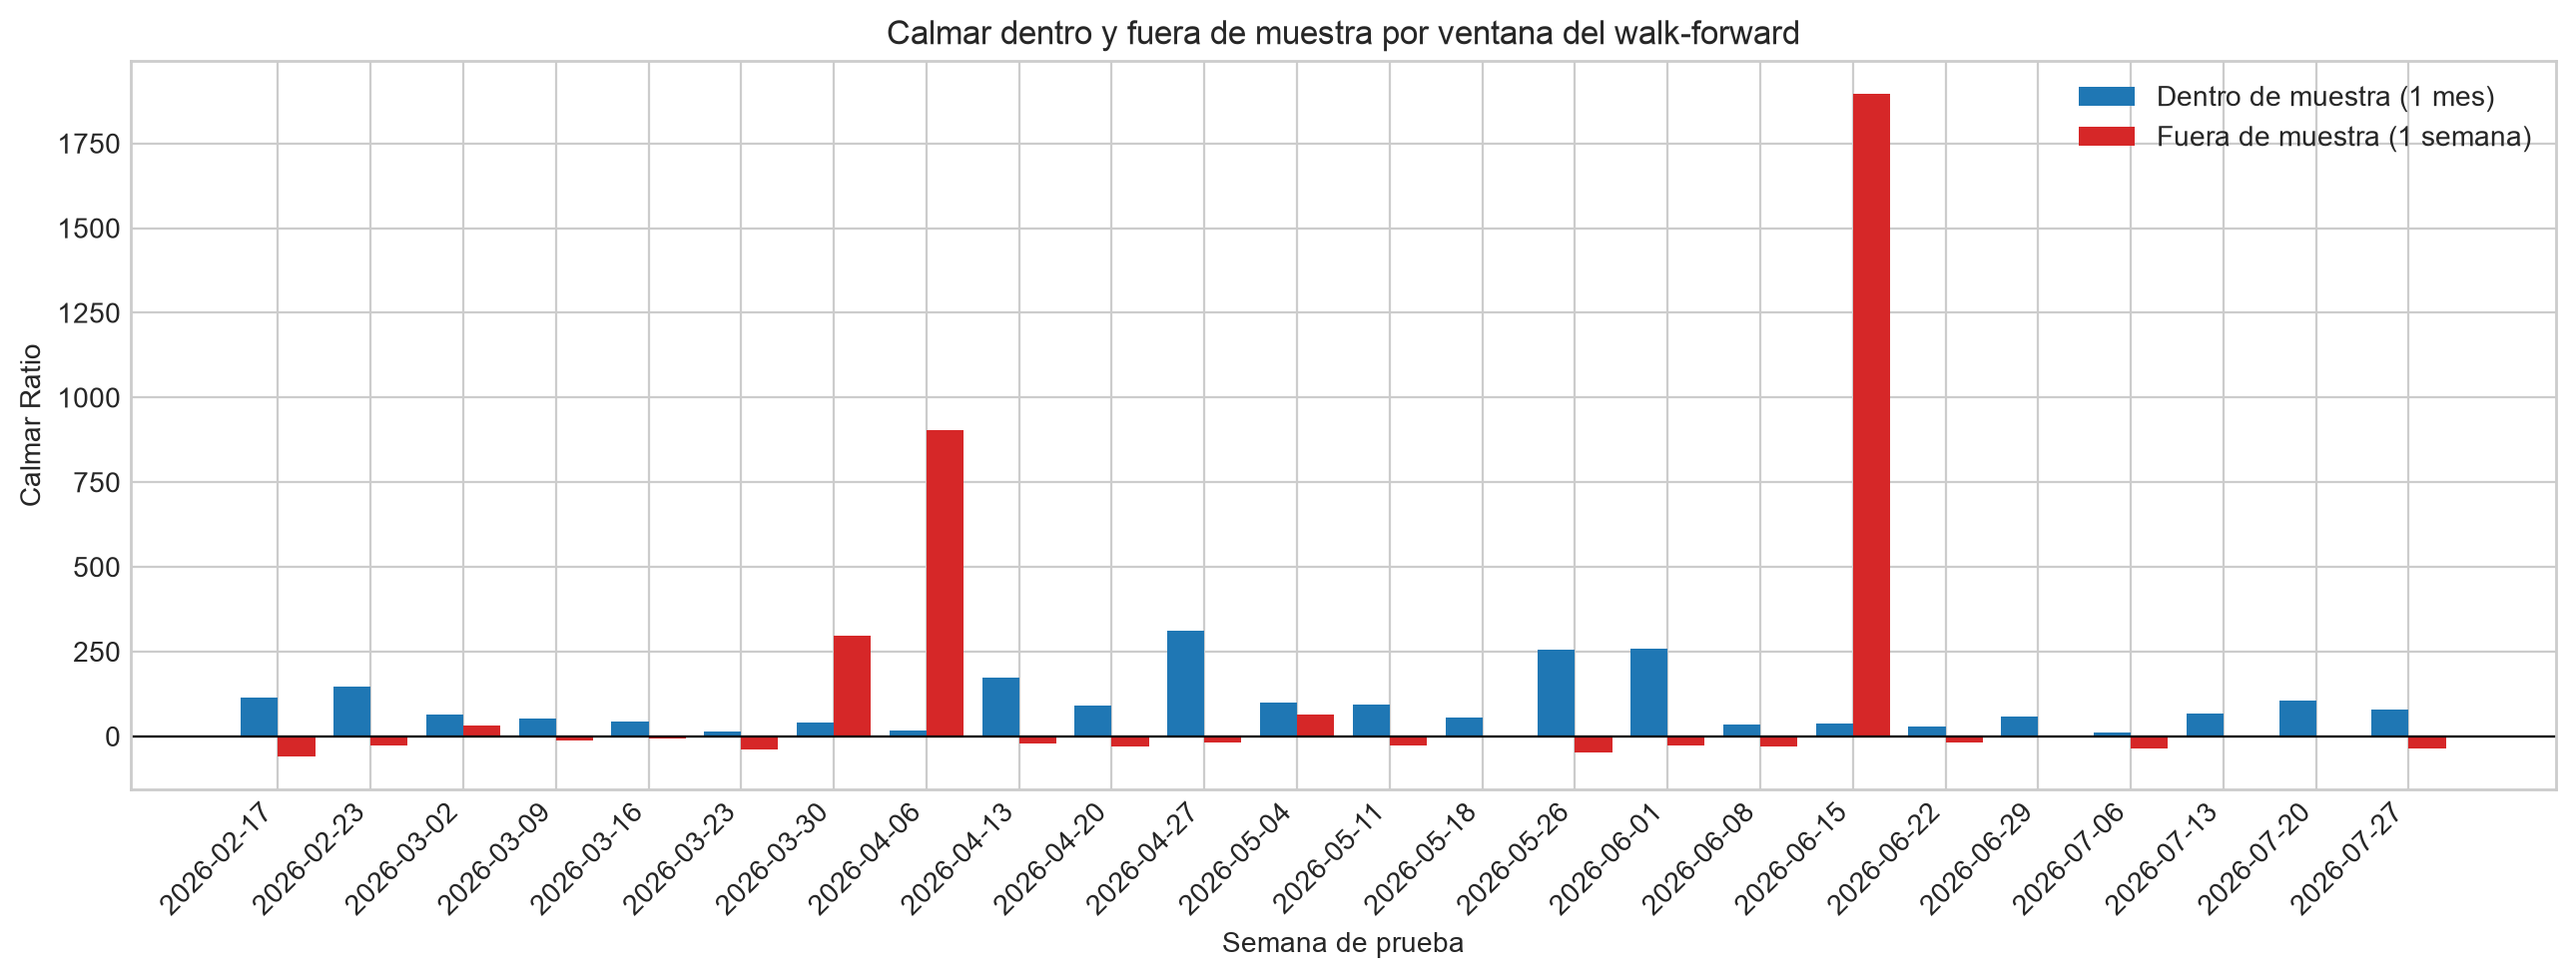

In [22]:
display(Image(FIG / "10_walk_forward.png"))

## 9. θ* congelado antes de tocar validation

θ* se optimiza con train y se congela en `docs/theta_congelado.json` con un commit propio antes de evaluar validation.

In [23]:
theta = json.loads((PROJECT_ROOT / "docs" / "theta_congelado.json").read_text(encoding="utf-8"))
commit = subprocess.run(["git", "log", "--format=%H %ad %s", "--date=iso", "--", "docs/theta_congelado.json"],
                        cwd=PROJECT_ROOT, capture_output=True, text=True).stdout.strip()
print("Commit de congelamiento:\n" + commit)
pd.DataFrame({r: p for r, p in theta["parametros"].items() if p is not None})

Commit de congelamiento:
62c84a0d8f83aa97da3a0d54d67c20be023a3ba2 2026-10-06 00:03:24 -0600 Etapa de ventanas en el repo, motor solo con posición objetivo, SPEC sin versiones
1ede7dd1e299aee495aab9d2766450a8711e3a6c 2026-10-05 23:17:54 -0600 Congela θ* optimizado con todo train
1973f19310bf7bb883c9d2d3c02d8fadea2ca870 2026-10-05 22:27:51 -0600 Congela θ* de la versión 3 con compra nocturna antes de evaluar validation
c592ead15ad918a331f70ea3346d2e177cdd8189 2026-10-05 21:58:20 -0600 Congela θ* de la versión 3 antes de evaluar validation
01f67f41e88f50e5bf1a452dfcb5e23761134dda 2026-10-05 21:56:40 -0600 Versión 3: Keltner, RSI y TRIX con posición de un día a otro
7a11f78193479253f9ea14f0518447b340b50946 2026-10-05 13:23:15 -0600 Congela θ* v2 con train + test antes de reevaluar validation
6ba1c50ed8cc543b59d94100473d640011827b77 2026-10-05 13:23:14 -0600 Reemplaza el backtest por el motor puro de la Act 06 con posición, sizing por riesgo y holding máximo
9a11fab6634e00a0848a1defbce71a36

,tendencia,reversion,crisis
kc_n,50.000000,50.000000,50.000000
kc_atr,26.000000,26.000000,26.000000
rsi_n,15.000000,15.000000,15.000000
trix_n,28.000000,28.000000,28.000000
memoria,15.000000,15.000000,15.000000
dias_tendencia,20.000000,20.000000,20.000000
sl_atr,7.732658,3.294069,2.584445
tp_atr,7.066533,8.890199,21.387361
riesgo,0.002554,0.007689,0.002689
umbral_vwap,0.003121,0.004728,0.005515


## 10. Métricas por conjunto

In [24]:
metricas = pd.read_csv(RES / "metricas.csv", index_col=0)
metricas.round(4)

,train,B&H train,test,B&H test,validation,B&H validation,train (WF),test (WF)
retorno_total,0.1425,0.1304,-0.0199,-0.0788,0.0110,0.1284,-0.0433,-0.0868
rendimiento_anualizado,0.6154,0.5547,-0.1114,-0.3818,0.0731,1.1828,-0.1436,-0.4126
volatilidad,0.1187,0.3592,0.1266,0.3832,0.2099,0.3520,0.0979,0.1018
sharpe,4.0989,1.4080,-0.8694,-1.0631,0.4392,2.3924,-1.5343,-5.1742
sortino,8.7541,2.0126,-1.6005,-1.4393,0.7854,3.8384,-2.1208,-5.6003
calmar,26.3454,3.3006,-2.7469,-2.1354,1.1731,10.9100,-3.0195,-4.6536
max_drawdown,-0.0234,-0.1681,-0.0405,-0.1788,-0.0623,-0.1084,-0.0475,-0.0887
win_rate,0.4839,NaN,0.3404,NaN,0.2941,NaN,0.3774,0.2812
payoff,2.1838,NaN,1.6460,NaN,2.5923,NaN,1.1519,0.8073
operaciones,62.0000,0.0000,47.0000,0.0000,34.0000,0.0000,53.0000,32.0000


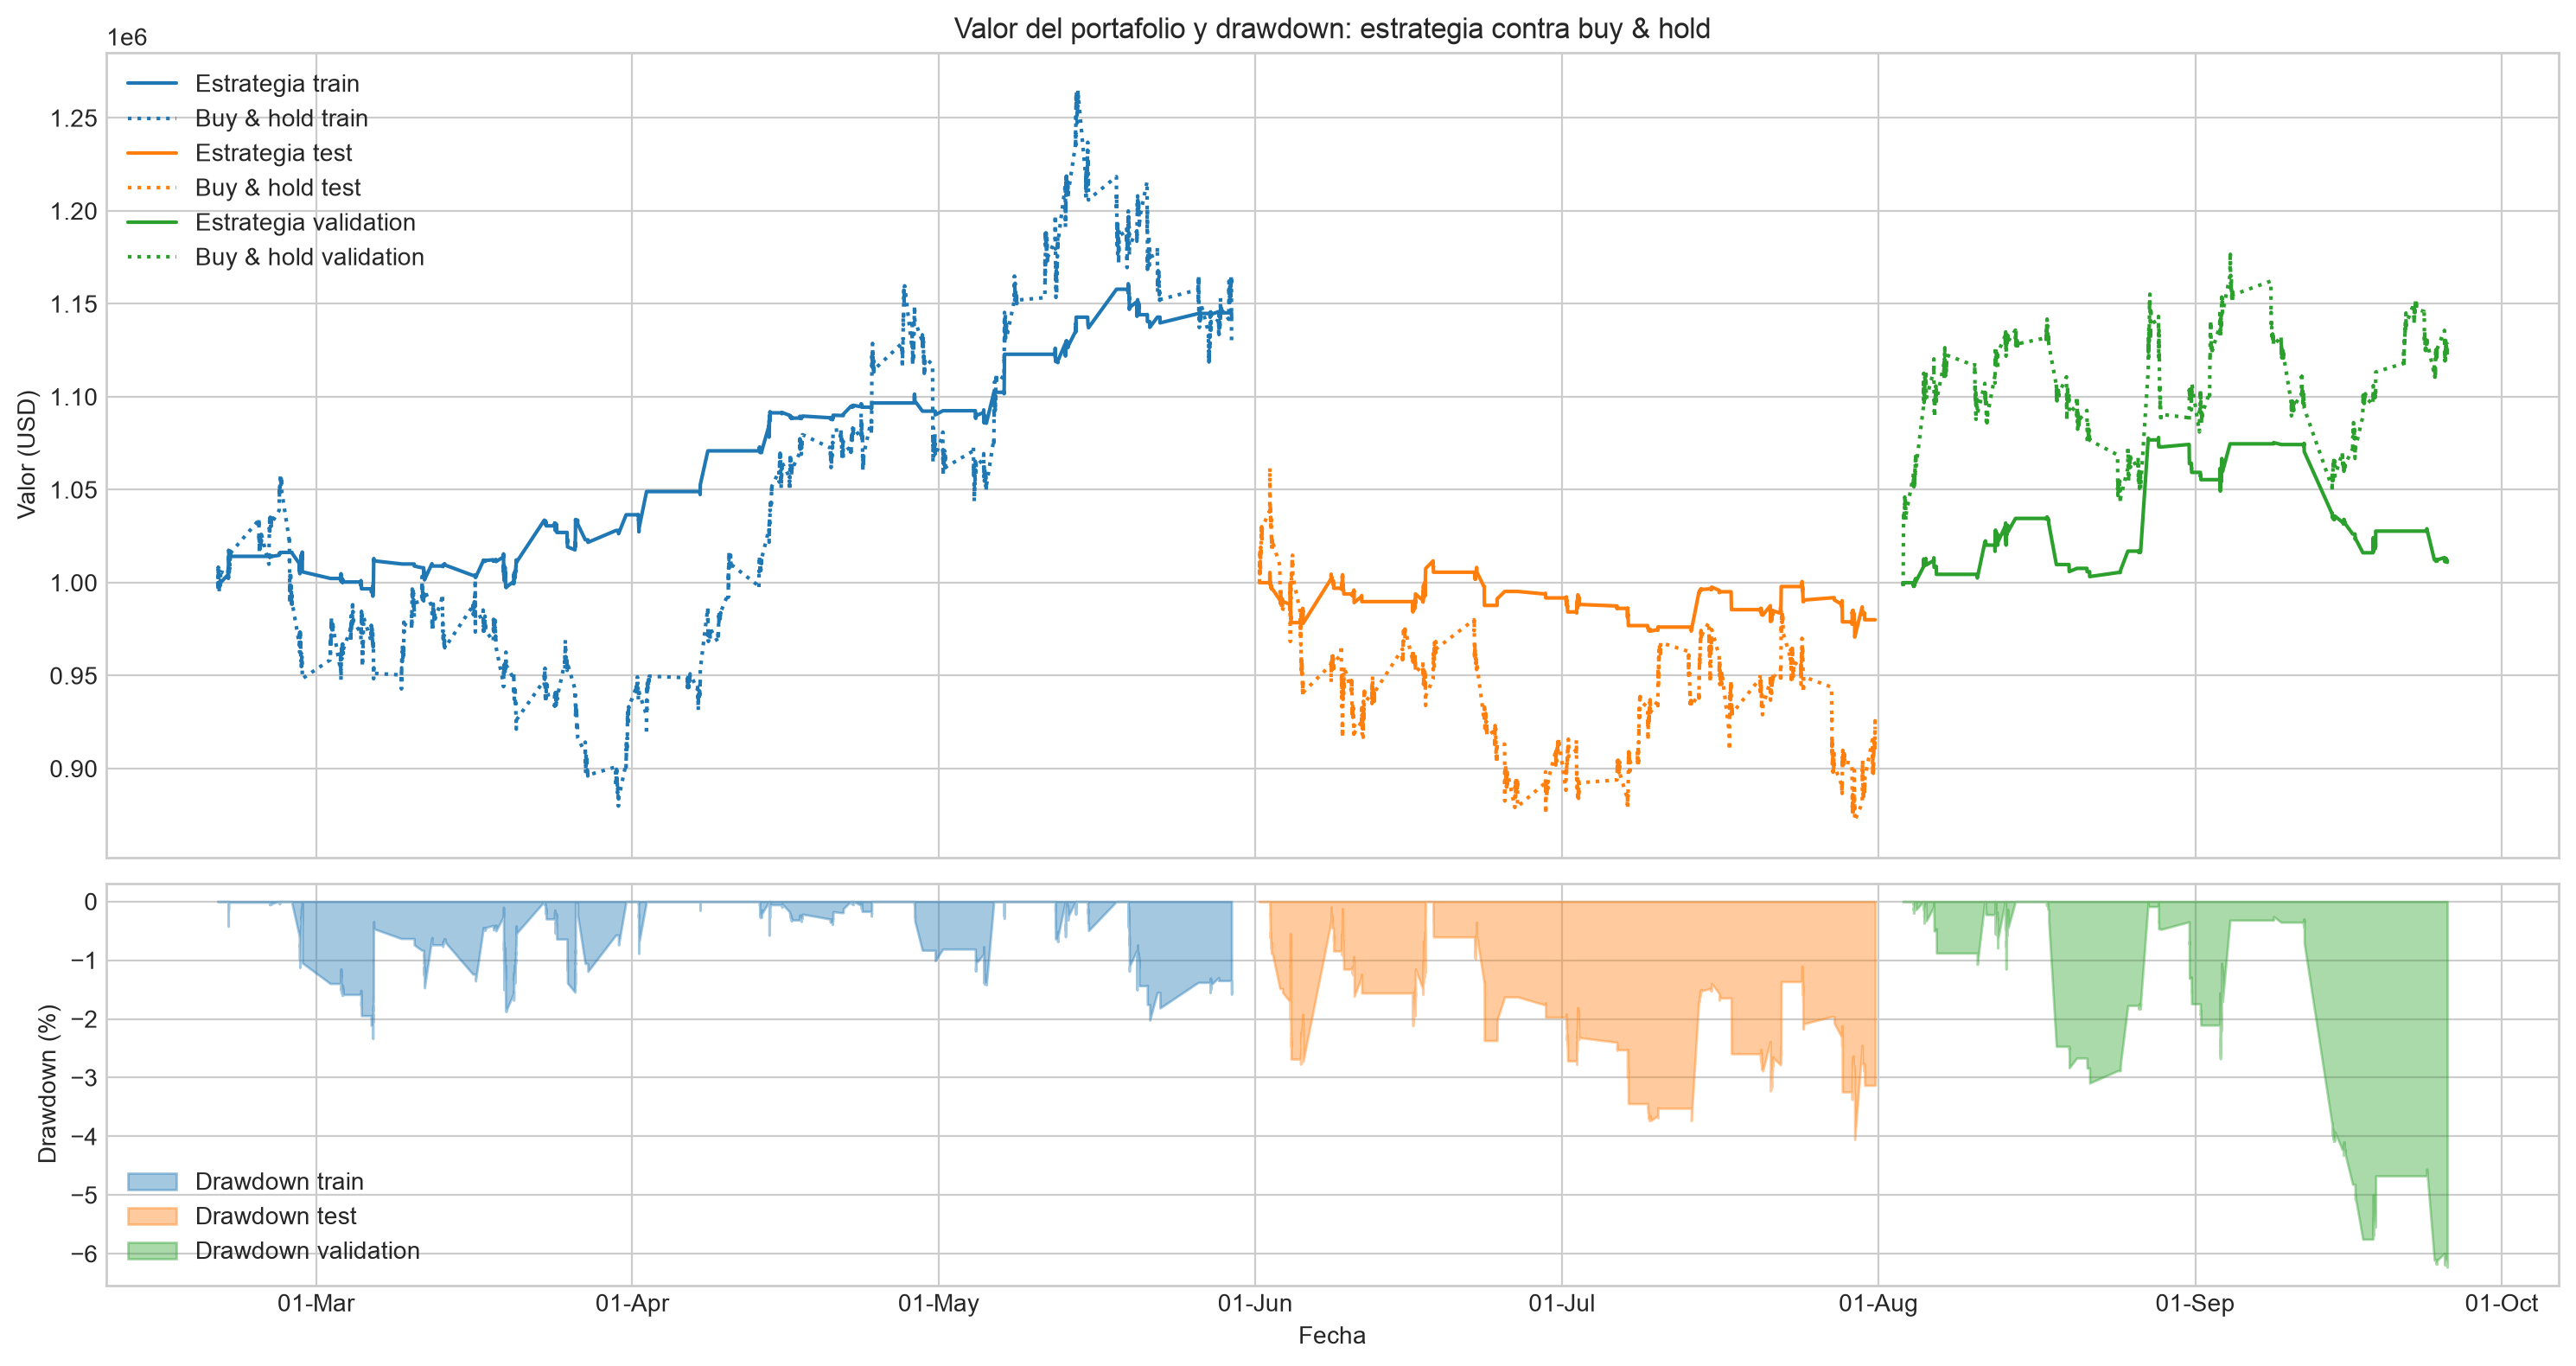

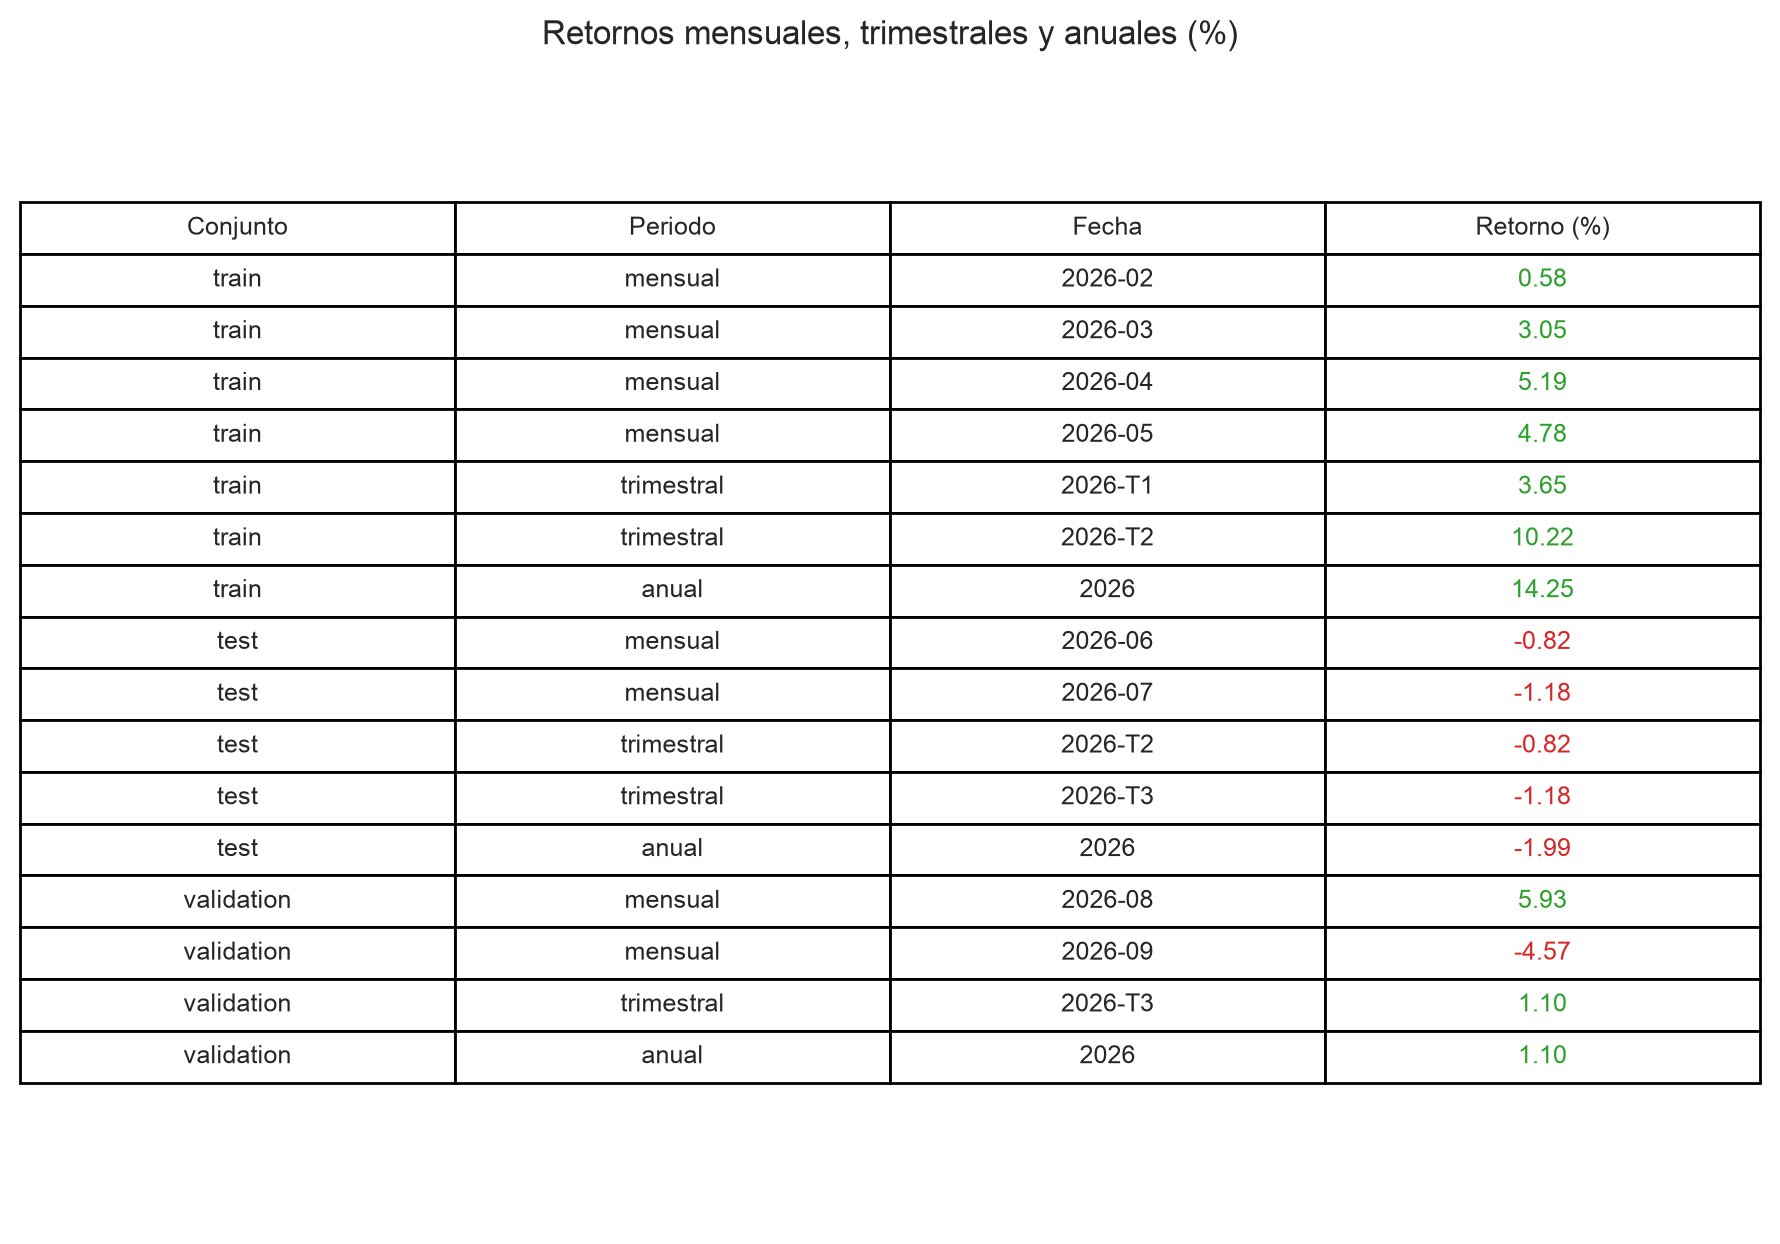

In [25]:
display(Image(FIG / "03_valor_drawdown.png"))
display(Image(FIG / "04_tabla_retornos.png"))

## 11. Costos y win rate de equilibrio

In [26]:
print("Win rate de equilibrio p* por configuración:", {k: round(v, 3) for k, v in resumen["win_rate_equilibrio"].items()})
print(f"Costo de ida y vuelta del SPEC: {resumen['costo_ida_vuelta']:.4%}")
pd.read_csv(RES / "costos_validation.csv").round(4)

Win rate de equilibrio p* por configuración: {'SPEC': 0.283, 'tendencia': 0.59, 'reversion': 0.352, 'crisis': 0.149}
Costo de ida y vuelta del SPEC: 0.2760%


,ida_vuelta_bps,sharpe,retorno_neto,equity_final,calmar,operaciones
0,0,1.9151,0.0612,1.061213e+06,9.5286,34
1,5,1.6507,0.0519,1.051934e+06,7.7112,34
2,10,1.3848,0.0427,1.042734e+06,5.9478,34
3,15,1.1175,0.0336,1.033611e+06,4.3755,34
4,20,0.8489,0.0246,1.024566e+06,2.9906,34
5,25,0.5794,0.0156,1.015596e+06,1.7395,34
6,30,0.3090,0.0067,1.006703e+06,0.6878,34
7,35,0.0380,-0.0021,9.978839e+05,-0.2005,34
8,40,-0.2335,-0.0109,9.891398e+05,-0.9536,34
9,45,-0.5051,-0.0195,9.804697e+05,-1.5937,34


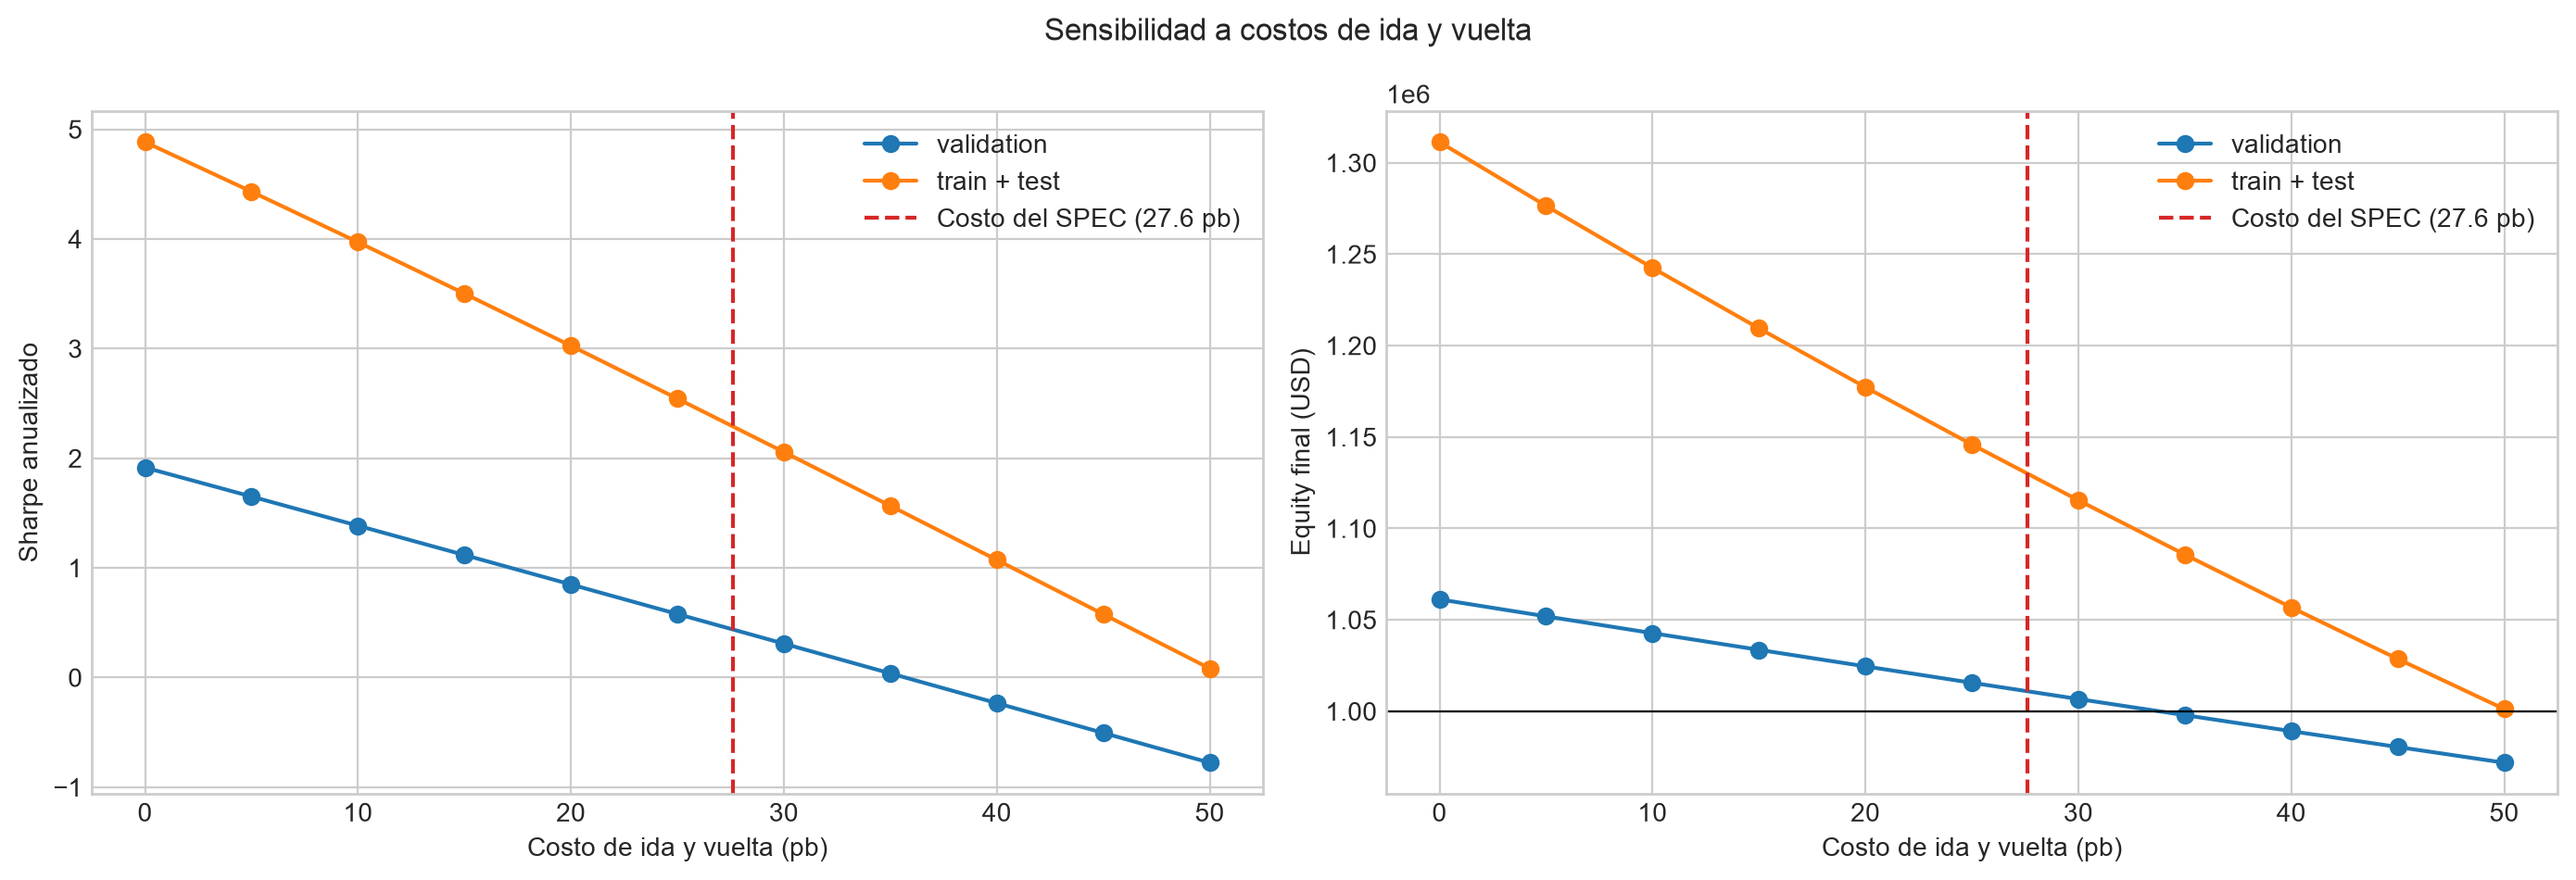

In [27]:
display(Image(FIG / "06_costos.png"))

## 12. De dónde sale el rendimiento: día contra noche

Suma de log-retornos de NVDA de la apertura al cierre (día) y del cierre a la apertura siguiente (noche), y aporte de cada parte de la estrategia.

In [28]:
pd.DataFrame(resumen["dia_noche_nvda"]).T

,dia,noche,sesiones
train,-0.017815,0.124228,102.0
test,-0.065150,-0.006519,43.0
validation,-0.071822,0.201376,39.0


In [29]:
pd.read_csv(RES / "dia_noche.csv", index_col=[0, 1]).round(4)

operaciones     pnl_usd  pnl_pct_capital  win_rate
conjunto   parte                                                    
train      dia             44  82719.2950           0.0827    0.4091
           noche           18  59754.3624           0.0598    0.6667
test       dia             35 -57977.0799          -0.0580    0.2571
           noche           12  38038.8910           0.0380    0.5833
validation dia             24   -296.6300          -0.0003    0.2500
           noche           10  11267.8363           0.0113    0.4000
train (WF) dia             41  -5484.6044          -0.0055    0.4146
           noche           12 -37775.0590          -0.0378    0.2500
test (WF)  dia             22 -27766.6561          -0.0278    0.3182
           noche           10 -61217.3011          -0.0612    0.2000